In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

!mv kaggle.json /root/.kaggle/

!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c petfinder-adoption-prediction

100% 1.94G/1.94G [00:49<00:00, 41.7MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile('petfinder-adoption-prediction.zip', 'r') as zip_ref:
    zip_ref.extractall('petfinder_data')

In [ ]:
os.listdir('petfinder_data')

['StateLabels.csv',
 'BreedLabels.csv',
 'test_images',
 'train_metadata',
 'test_metadata',
 'PetFinder-BreedLabels.csv',
 'PetFinder-ColorLabels.csv',
 'PetFinder-StateLabels.csv',
 'color_labels.csv',
 'ColorLabels.csv',
 'train_sentiment',
 'test',
 'state_labels.csv',
 'breed_labels.csv',
 'test_sentiment',
 'train',
 'train_images']

In [ ]:
print("Содержимое папки train:")
print(os.listdir('petfinder_data/train'))

Содержимое папки train:
['train.csv']


In [ ]:
import pandas as pd

train = pd.read_csv('petfinder_data/train/train.csv')
# Шапка
print("Первые 5 строк train.csv:")
display(train.head())

print("\nРазмер данных:", train.shape)
print("\nИнформация по колонкам:")
train.info()

print("\nКоличество пропусков по колонкам:")
print(train.isnull().sum())
# бейзлайн
baseline_class = train['AdoptionSpeed'].mode()[0]
print(f"\nBaseline: всегда предсказываем класс {baseline_class}")

Первые 5 строк train.csv:


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2



Размер данных: (14993, 24)

Информация по колонкам:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           14993 non-null  int64  
 1   Name           13728 non-null  object 
 2   Age            14993 non-null  int64  
 3   Breed1         14993 non-null  int64  
 4   Breed2         14993 non-null  int64  
 5   Gender         14993 non-null  int64  
 6   Color1         14993 non-null  int64  
 7   Color2         14993 non-null  int64  
 8   Color3         14993 non-null  int64  
 9   MaturitySize   14993 non-null  int64  
 10  FurLength      14993 non-null  int64  
 11  Vaccinated     14993 non-null  int64  
 12  Dewormed       14993 non-null  int64  
 13  Sterilized     14993 non-null  int64  
 14  Health         14993 non-null  int64  
 15  Quantity       14993 non-null  int64  
 16  Fee            14993 non-null  int64  
 1

Что можно сказать:

-Всего 14993 записи, 24 колонки

-Пропуски есть только в Name (1265) и Description (13)

-Остальные колонки полностью заполнены

In [ ]:
# Обработка пропусов

# Name: заполняем пропуски как "NoName"
train['Name'] = train['Name'].fillna('NoName')

# Description - на пустую строку
train['Description'] = train['Description'].fillna('')

missing_counts = train[['Name','Description']].isnull().sum()
print("Пропуски после заполнения:")
display(missing_counts)

Пропуски после заполнения:


,0
Name,0
Description,0


# Начинаем EDA

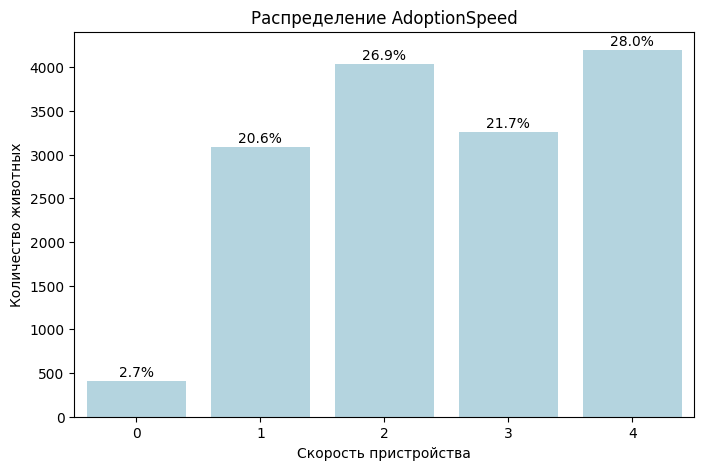

Количество животных по классам AdoptionSpeed:


,count
AdoptionSpeed,
0,410
1,3090
2,4037
3,3259
4,4197



Доля каждого класса (%):


,count
AdoptionSpeed,
0,2.734609
1,20.609618
2,26.925899
3,21.736811
4,27.993063


In [ ]:
# Распределение нашей целевой переменной AdoptionSpeed на графике

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='AdoptionSpeed', data=train, color='lightblue')

plt.title('Распределение AdoptionSpeed')
plt.xlabel('Скорость пристройства')
plt.ylabel('Количество животных')

# Добавляем подписи с процентами
total = len(train)
for p in plt.gca().patches:
    height = p.get_height()
    plt.text(p.get_x() + p.get_width()/2., height + 50, f'{height/total*100:.1f}%',
             ha="center", fontsize=10)

plt.show()

# Дисбаланса классов
adoption_counts = train['AdoptionSpeed'].value_counts().sort_index()
adoption_percent = adoption_counts / adoption_counts.sum() * 100

print("Количество животных по классам AdoptionSpeed:")
display(adoption_counts)
print("\nДоля каждого класса (%):")
display(adoption_percent)

В исходном датасете целевая переменная была представлена в виде пяти категорий скорости пристройства.

0	- Животное пристроили очень быстро (в течение первой недели)

1	- Пристроили в течение месяца

2	- Пристроили в течение 2–3 месяцев

3	- Пристраивали очень медленно

4	- Не было пристроено вообще

Выводы:
- Классы сильно несбалансированы: самые редкие - класс 0 (самое быстрое пристройство, 2.7%), самые частые - класс 4 (28%).
- Дисбаланс классов важно учитывать при обучении модели.

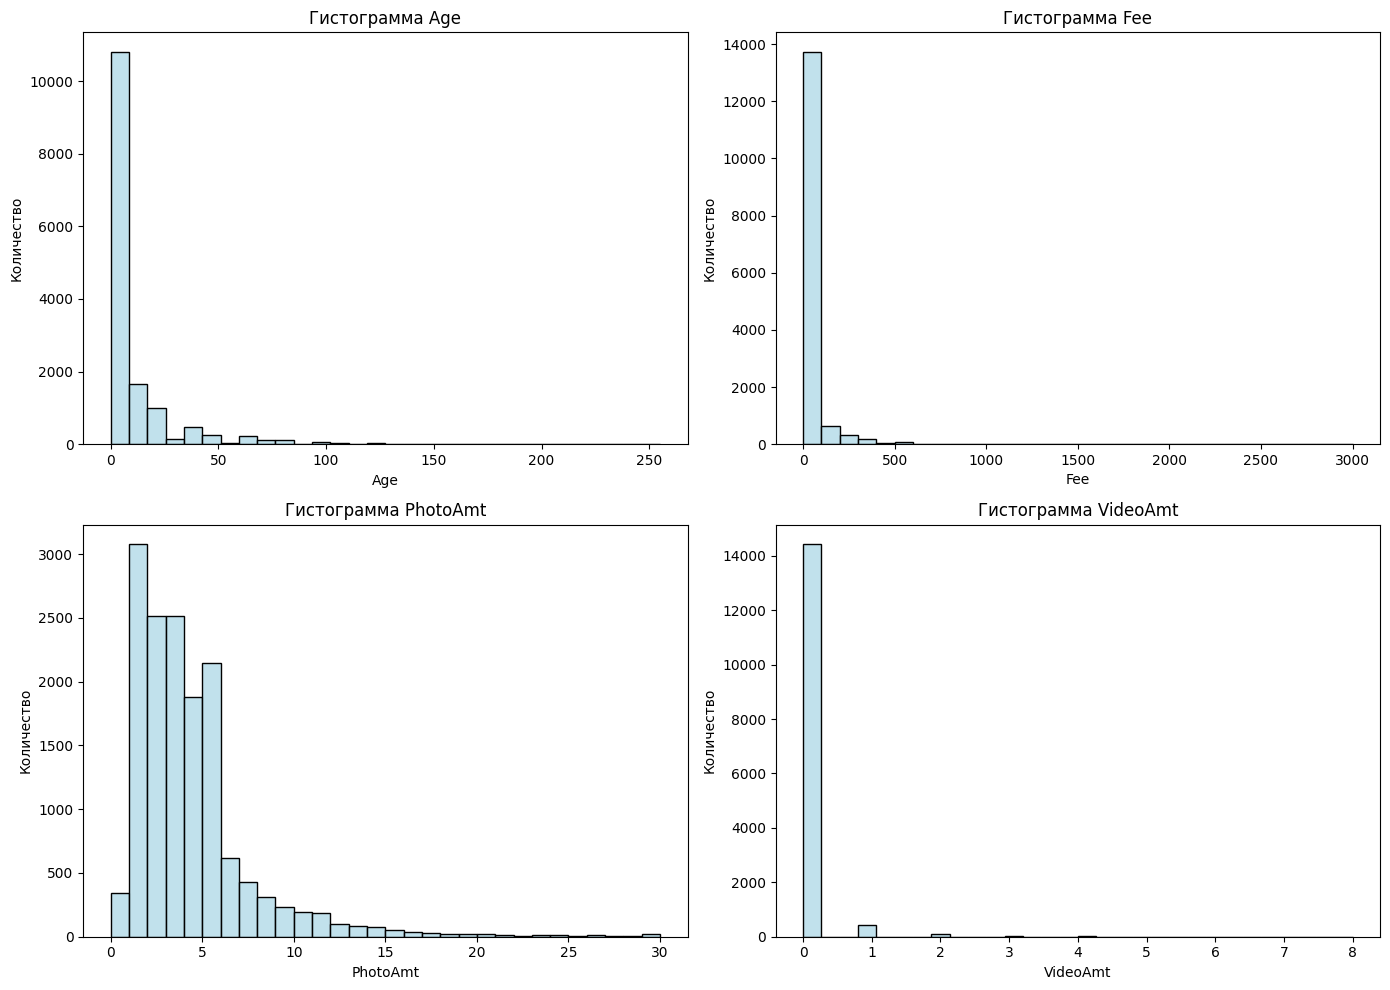

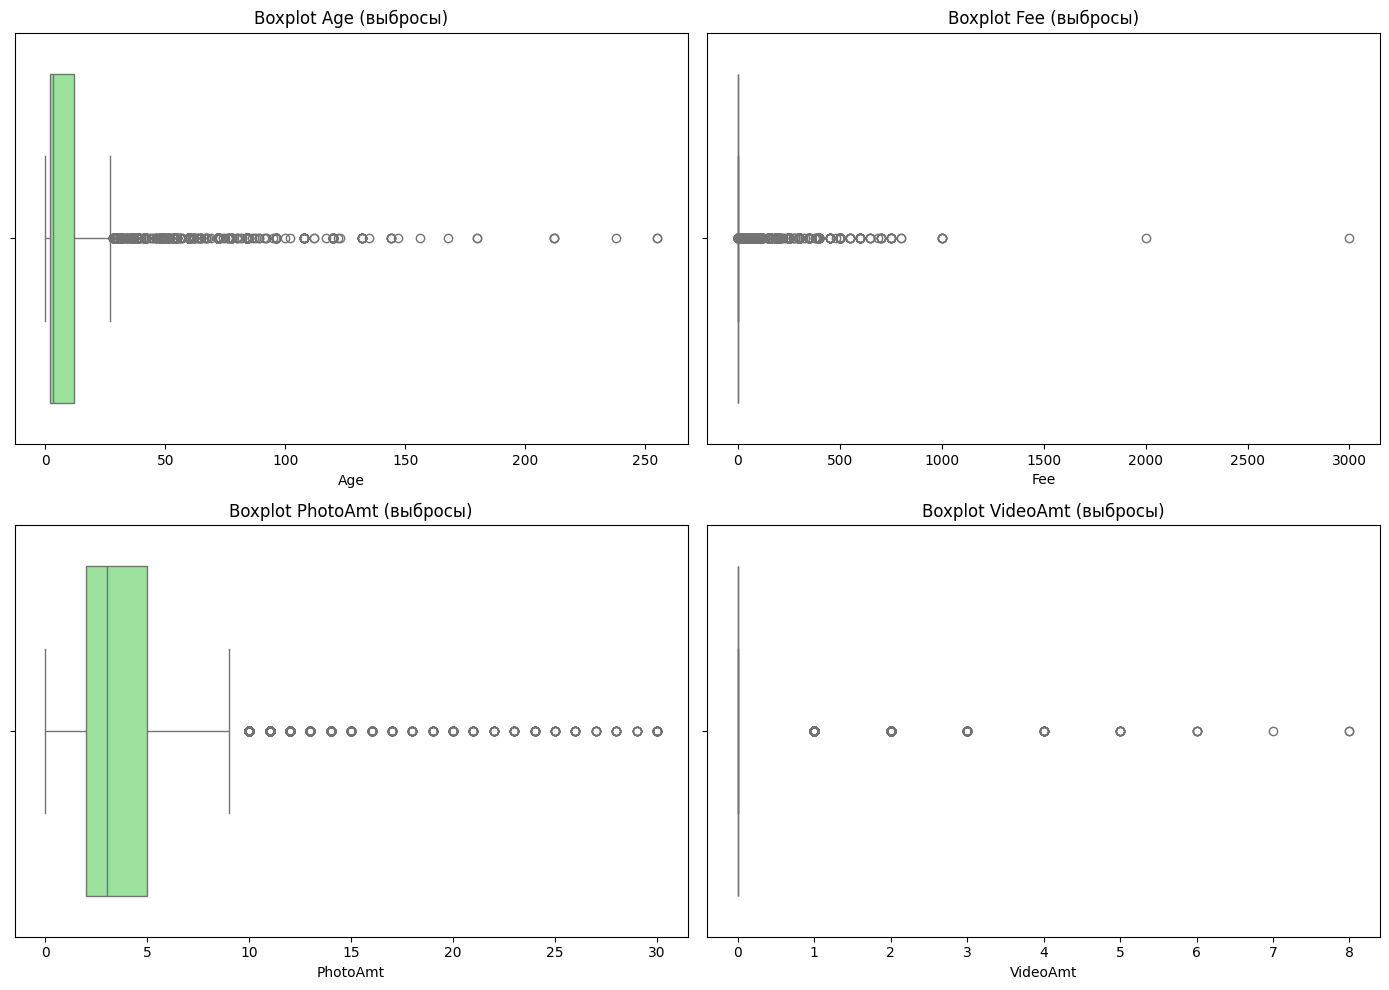

Age: min=0, max=255, median=3.0, mean=10.45
  Выбросов: 1501 (10.01%)

Fee: min=0, max=3000, median=0.0, mean=21.26
  Выбросов: 2330 (15.54%)

PhotoAmt: min=0.0, max=30.0, median=3.0, mean=3.89
  Выбросов: 922 (6.15%)

VideoAmt: min=0, max=8, median=0.0, mean=0.06
  Выбросов: 574 (3.83%)



In [ ]:
# Числовые признаки с проверкой выбросов

numeric_cols = ['Age', 'Fee', 'PhotoAmt', 'VideoAmt']

plt.figure(figsize=(14,10))

for i, col in enumerate(numeric_cols):
    # Гистограмма
    plt.subplot(2, 2, i+1)
    sns.histplot(train[col], bins=30, kde=False, color='lightblue')
    plt.title(f'Гистограмма {col}')
    plt.xlabel(col)
    plt.ylabel('Количество')

plt.tight_layout()
plt.show()

# Для выявления выбросов
plt.figure(figsize=(14,10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(x=train[col], color='lightgreen')
    plt.title(f'Boxplot {col} (выбросы)')
plt.tight_layout()
plt.show()

# Вывод по признакам
for col in numeric_cols:
    print(f"{col}: min={train[col].min()}, max={train[col].max()}, median={train[col].median()}, mean={train[col].mean():.2f}")
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    outliers = train[(train[col] < q1 - 1.5*iqr) | (train[col] > q3 + 1.5*iqr)]
    print(f"  Выбросов: {len(outliers)} ({len(outliers)/len(train)*100:.2f}%)\n")

Распределение числовых признаков показывает наличие редких выбросов:
- Age:

Медиана 3 месяца - большинство животных действительно очень молодые (котята/щенки)

Среднее 10.5 месяцев - вытягивается за счёт более взрослых животных

255 месяцев (21 год) - это реальный возраст, но таких единицы (они и создают выбросы)

- Fee: редкие высокие значения, но большинство питомцев имеют стоимость менее 500;
- PhotoAmt и VideoAmt: большинство питомцев имеют меньше 5 фото/видео;

Выбросы составляют относительно небольшой процент данных, поэтому их влияние на модели умеренное.



Статистика после обработки выбросов:
            Age       Fee  PhotoAmt  VideoAmt
count  14993.00  14993.00  14993.00  14993.00
mean      10.42     13.95      3.89      0.06
std       17.93     38.57      3.49      0.35
min        0.00      0.00      0.00      0.00
25%        2.00      0.00      2.00      0.00
50%        3.00      0.00      3.00      0.00
75%       11.00      0.00      5.00      0.00
max      238.00    150.00     30.00      8.00


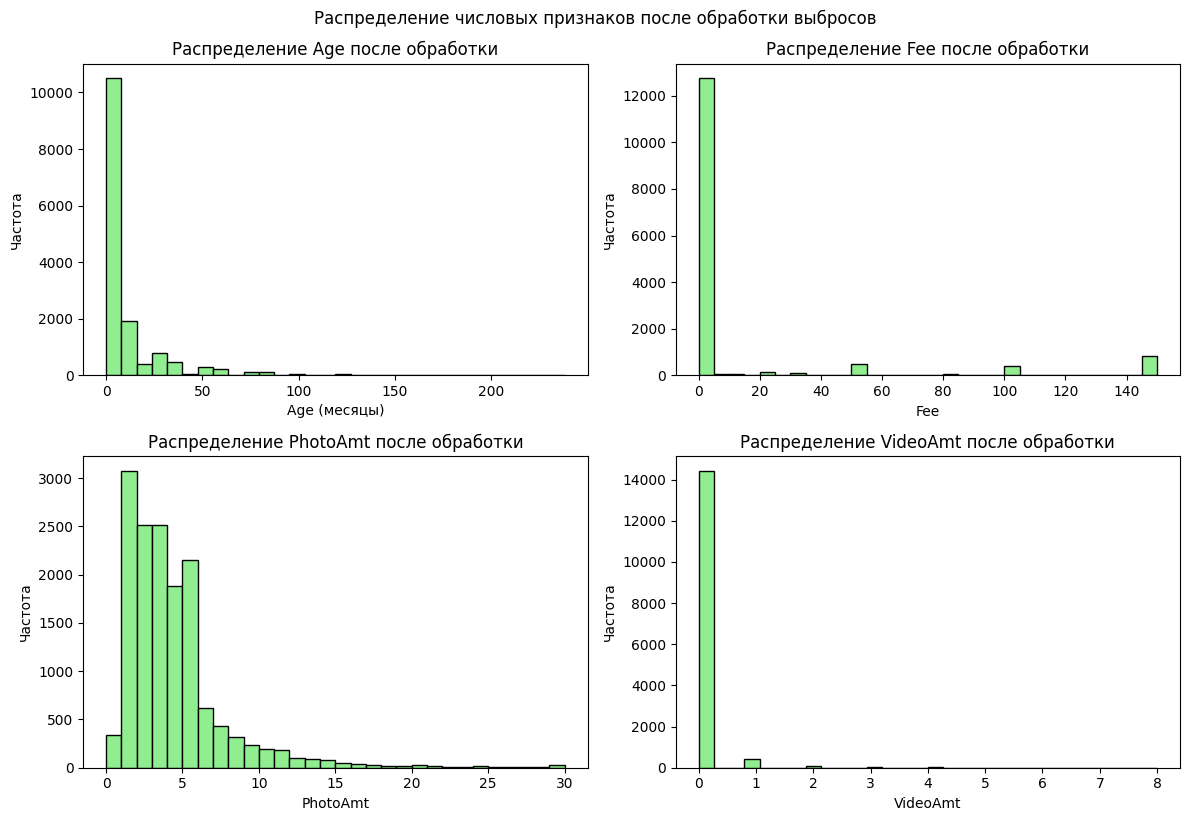

In [ ]:
# Обработка выбросов (только на train)
# Квантили и медиана рассчитываются только на train,
# чтобы избежать data leakage

# Age заменяем значения старше разумного порога (животные старше 20 лет = 240 месяцев)

age_median = train.loc[train['Age'] <= 240, 'Age'].median()  # 20 лет
train.loc[train['Age'] > 240, 'Age'] = age_median

# Fee ограничиваем сверху 95-м перцентилем
fee_cap = train['Fee'].quantile(0.95)
train['Fee'] = train['Fee'].clip(upper=fee_cap)

# Проверка распределений
numeric_cols = ['Age', 'Fee', 'PhotoAmt', 'VideoAmt']

print("Статистика после обработки выбросов:")
print(train[numeric_cols].describe().round(2))

# Визуализация
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 2, i+1)
    plt.hist(train[col], bins=30, color='lightgreen', edgecolor='black')
    plt.title(f'Распределение {col} после обработки')
    plt.xlabel(col + (' (месяцы)' if col == 'Age' else ''))
    plt.ylabel('Частота')
plt.tight_layout()
plt.suptitle('Распределение числовых признаков после обработки выбросов', y=1.02)
plt.show()

**Возраст (Age):**

Возраст указан в месяцах

Медианный возраст составляет 3 месяца - большинство животных поступают в приют совсем малышами

Средний возраст - 10.4 месяца, что выше медианы из-за наличия взрослых животных

Максимальный возраст после обработки - 238 месяцев (примерно 19.8 лет) - единичные случаи

Животные старше 20 лет (240 месяцев) встречаются крайне редко и были заменены на медиану

**Плата за усыновление (Fee):**

Ограничена 95-м перцентилем (значение 150)

Большинство животных (более 75%) выставляются бесплатно (медиана = 0)

Максимальная стоимость после обработки - 150 (было 3000)

**Количество фото (PhotoAmt):**

Большинство животных имеют 2-5 фотографий

Медиана - 3 фото

Встречаются животные с большим количеством фото (до 30), но это не является выбросом

**Количество видео (VideoAmt):**

Подавляющее большинство животных (более 90%) не имеют видео

Медиана = 0

Наличие видео - редкий, но потенциально значимый признак

/tmp/ipykernel_234/1524586867.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=plot_col, palette='pastel')
/tmp/ipykernel_234/1524586867.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=plot_col, palette='pastel')
/tmp/ipykernel_234/1524586867.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=plot_col, palette='pastel')
/tmp/ipykernel_234/1524586867.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for 

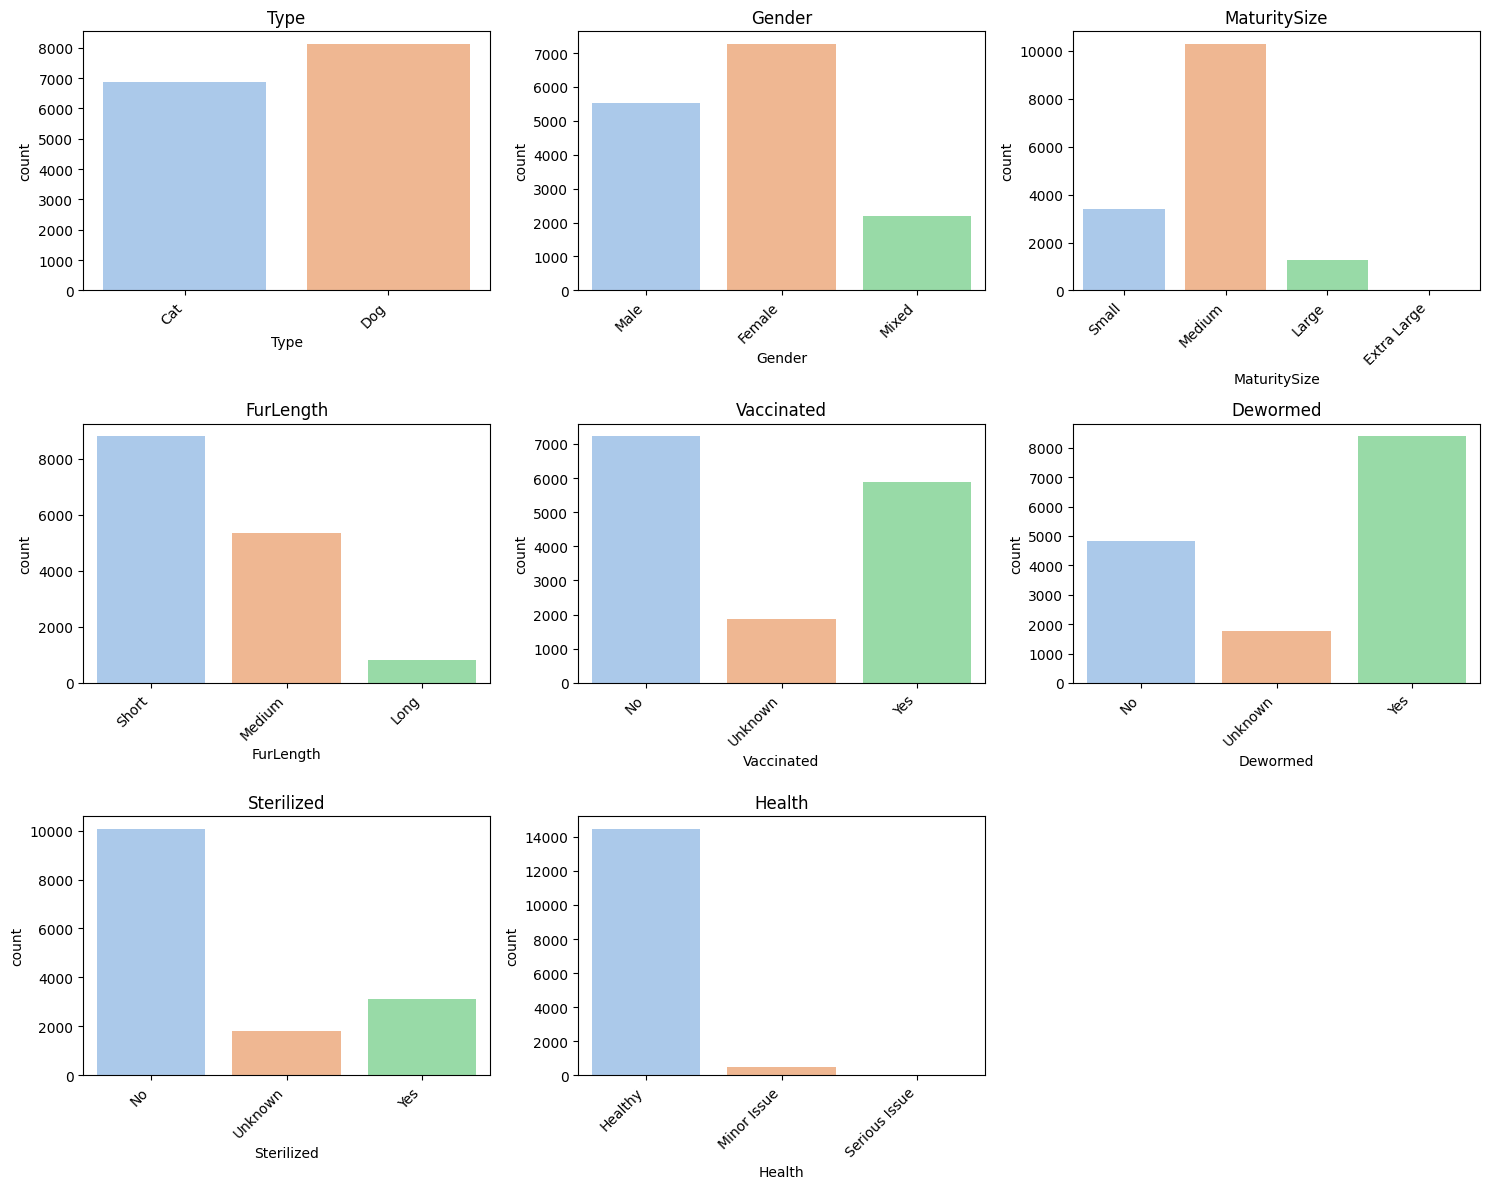

In [ ]:
# Словарики для расшифровки
type_map = {1: 'Dog', 2: 'Cat'}
gender_map = {1: 'Male', 2: 'Female', 3: 'Mixed'}
maturity_map = {1: 'Small', 2: 'Medium', 3: 'Large', 4: 'Extra Large'}
fur_map = {1: 'Short', 2: 'Medium', 3: 'Long'}
yesno_map = {1: 'Yes', 2: 'No', 3: 'Unknown', 4: 'Other'}
health_map = {1: 'Healthy', 2: 'Minor Issue', 3: 'Serious Issue', 4: 'Unknown'}

categorical_cols = ['Type', 'Gender', 'MaturitySize', 'FurLength',
                    'Vaccinated', 'Dewormed', 'Sterilized', 'Health']
maps = [type_map, gender_map, maturity_map, fur_map,
        yesno_map, yesno_map, yesno_map, health_map]

plt.figure(figsize=(15,12))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)

    # Преобразуем числовые коды в метки для визуализации
    current_map = maps[i]
    plot_col = train[col].map(current_map).fillna('Unknown')

    sns.countplot(x=plot_col, palette='pastel')
    plt.xticks(rotation=45, ha='right')
    plt.title(col)

plt.tight_layout()
plt.show()

**Расшифровка категориальных признаков (PetFinder)**


**Type** (Тип животного):

1 - Dog (Собака) **Немного больше**

2 - Cat (Кошка)


**Gender** (Пол):

1 - Male (Мальчик)

2 - Female (Девочка)  **Немного больше**

3 - Mixed/Unknown (Трудноопределяемый?)


**MaturitySize** (Размер при взрослении):

1 - Small (Маленький)

2 - Medium (Средний) **Чаще встречаеющийся размер животных**

3 - Large (Большой)

4 - Extra Large (Очень большой) **Очень редкие экземпляры**


**FurLength** (Длина шерсти):

1 - Short (Короткая) **Встречается чаще**

2 - Medium (Средняя)

3 - Long (Длинная)  **Меньше всего**


**Vaccinated** (Вакцинальный статус):

1 - Yes (Вакцинирован) **Таких животных чуть меньше**

2 - No (Не вакцинирован) **Таких животных больше**

3 - Unknown (Неизвестно)



**Dewormed** (Статус животного по дегельминтизации):

1 - Yes (Обработка проведена) **Таких животных больше**

2 - No (Обработка отсутствует) **Таких животных меньше**

3 - Unknown (Неизвестно) **Небольшое количество**



**Sterilized** (Стерилизация/кастрация):

1 - Yes (Процедура проведена) **Значительно меньше**

2 - No (процедура НЕ проведена) **Таких животных больше**

3 - Unknown (Неизвестно)



**Health** (Здоровье):

1 - Healthy (Здоровое животное) **Таких животных большинство**

2 - Minor Issue (Имеется небольшая проблема) **Незначительное количество**

3 - Serious Issue (Имеется более серьёзная проблема) **Очень редкие эксземпляры**


Корреляция числовых признаков с AdoptionSpeed:


,AdoptionSpeed
AdoptionSpeed,1.000000
Age,0.099386
Fee,0.015559
VideoAmt,-0.000571
PhotoAmt,-0.023233


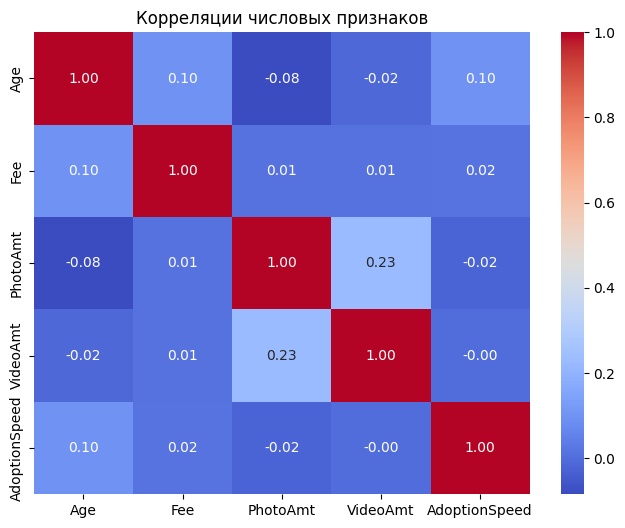

/tmp/ipykernel_234/3250922800.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y=col, data=train, palette='pastel')
/tmp/ipykernel_234/3250922800.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y=col, data=train, palette='pastel')
/tmp/ipykernel_234/3250922800.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y=col, data=train, palette='pastel')
/tmp/ipykernel_234/3250922800.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed 

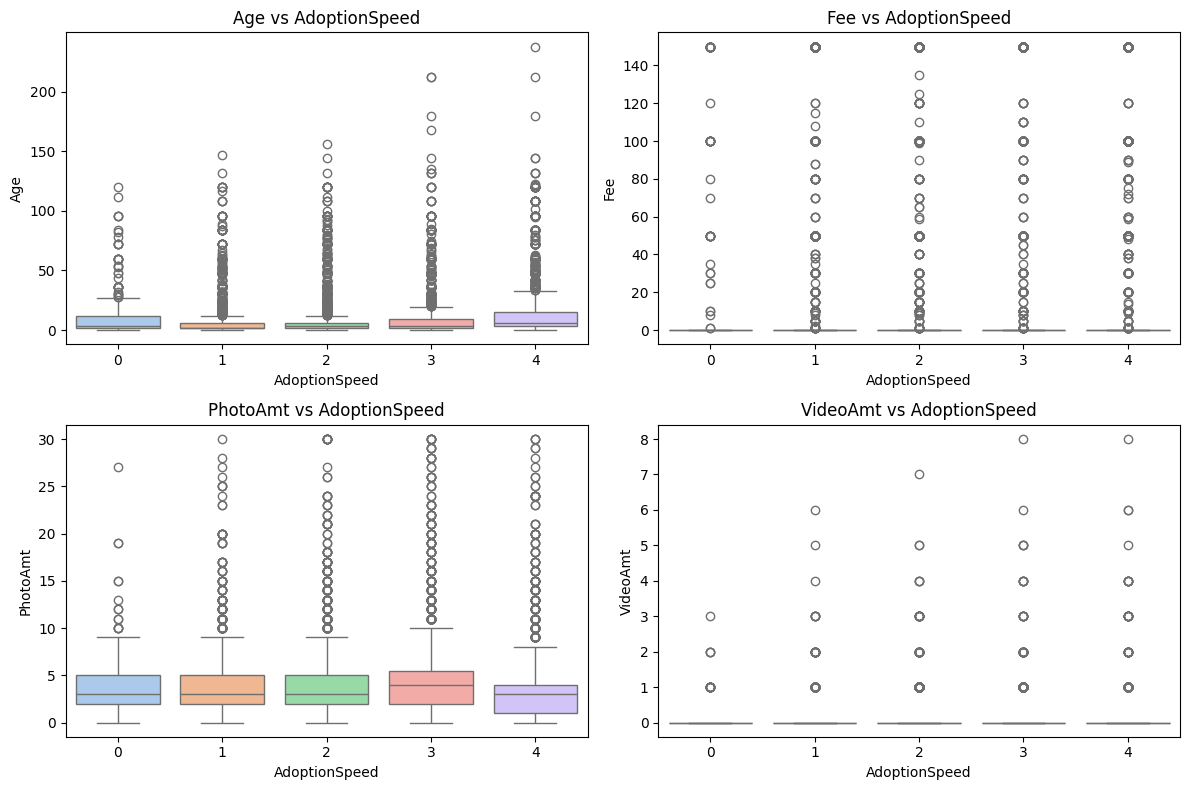

Age: выбросов = 1539 (10.26%)
Fee: выбросов = 2330 (15.54%)
PhotoAmt: выбросов = 922 (6.15%)
VideoAmt: выбросов = 574 (3.83%)


In [ ]:
# Числовые признаки и связь с AdoptionSpeed

# Выбираем числовые признаки
numeric_cols = ['Age', 'Fee', 'PhotoAmt', 'VideoAmt']

# Корреляция с целевой переменной
corr_with_target = train[numeric_cols + ['AdoptionSpeed']].corr()['AdoptionSpeed'].sort_values(ascending=False)
print("Корреляция числовых признаков с AdoptionSpeed:")
display(corr_with_target)

# Визуализация корреляционной матрицы
plt.figure(figsize=(8,6))
sns.heatmap(train[numeric_cols + ['AdoptionSpeed']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляции числовых признаков")
plt.show()

# Распределение числовых признаков по классам AdoptionSpeed
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='AdoptionSpeed', y=col, data=train, palette='pastel')
    plt.title(f'{col} vs AdoptionSpeed')
plt.tight_layout()
plt.show()

# Проверка выбросов по IQR
for col in numeric_cols:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = train[(train[col] < lower) | (train[col] > upper)]
    print(f"{col}: выбросов = {len(outliers)} ({len(outliers)/len(train)*100:.2f}%)")

**По тепловой карте корреляций:**
AdoptionSpeed с другими числовыми признаками:

Age имеет небольшую положительную корреляцию (0.099). Это значит, что животные старшего возраста (в месяцах) чуть дольше ждут пристройства. Уточнение: возраст измеряется в месяцах, поэтому даже небольшое увеличение возраста (например, с 3 до 12 месяцев) уже влияет на скорость усыновления.

Fee, PhotoAmt, VideoAmt почти не коррелируют с целевой переменной. Их влияние на AdoptionSpeed минимальное.

**Вывод:** из числовых признаков Age имеет наибольшую значимость, остальные скорее второстепенные.

**По боксплотам с распределением по классам AdoptionSpeed:**
Age: видно, что чем выше возраст (в месяцах), тем чаще животное попадает в более «медленные» классы пристройства. Медианный возраст для классов 0-1 составляет около 2-3 месяцев, для классов 3-4 - 6-12 месяцев. Есть выбросы (животные старше 20 лет), которые были обработаны.

Fee: распределение сильно скошено, большинство животных с нулевой платой.

PhotoAmt и VideoAmt: большинство животных имеют мало фото и видео, выбросы есть, но их влияние на AdoptionSpeed минимальное.

**Вывод:** боксплоты подтверждают, что Age имеет наибольшее влияние на AdoptionSpeed, остальные признаки меньше. Корректировка выбросов была оправдана.

По количеству выбросов:
Наибольшее количество выбросов у Fee (15%) и Age (10.3%).

Фото и видео выбиваются реже, но их влияние на целевую переменную слабое.

**Вывод**: выбросы в Age и Fee обработаны (Age: значения старше 20 лет заменены на медиану, Fee: ограничена 95-м перцентилем), что позволило получить более «чистые» данные для моделей.

/tmp/ipykernel_234/822836803.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_mean.index, y=type_mean.values, palette='pastel')
/tmp/ipykernel_234/822836803.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_mean.index, y=gender_mean.values, palette='pastel')
/tmp/ipykernel_234/822836803.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=size_mean.index, y=size_mean.values, palette='pastel')


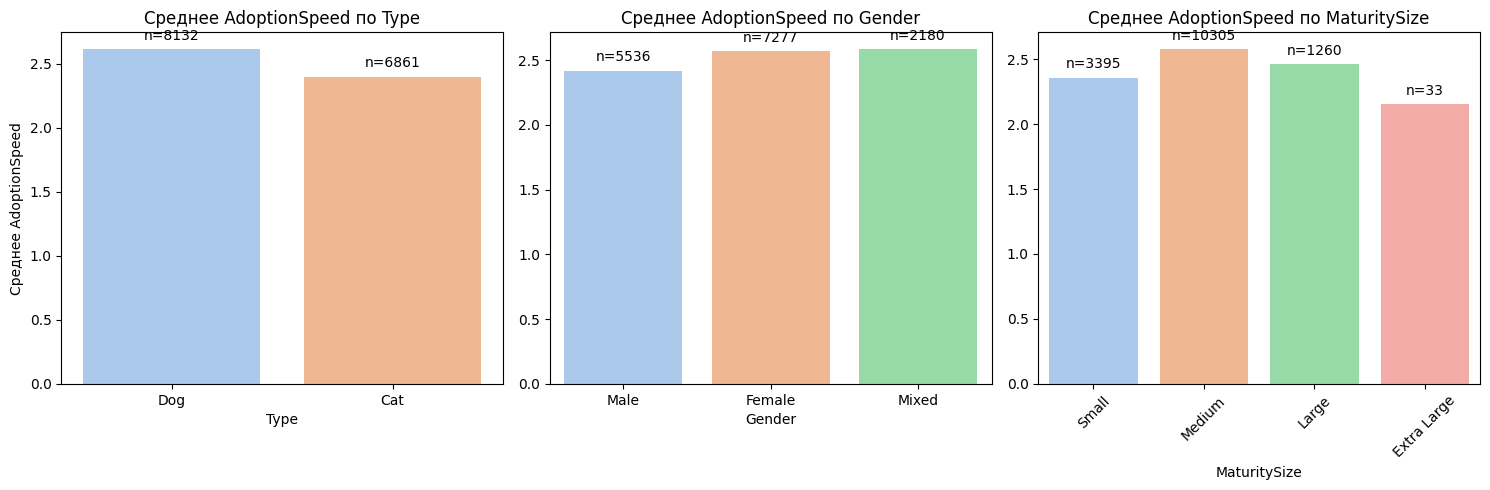

In [ ]:
# Средняя AdoptionSpeed по категориям (сразу с размером выборки)

# Средние AdoptionSpeed
type_mean = train.groupby('Type')['AdoptionSpeed'].mean()
gender_mean = train.groupby('Gender')['AdoptionSpeed'].mean()
size_mean = train.groupby('MaturitySize')['AdoptionSpeed'].mean()

# Размер выборки
type_count = train.groupby('Type').size()
gender_count = train.groupby('Gender').size()
size_count = train.groupby('MaturitySize').size()

plt.figure(figsize=(15,5))

# Tип
plt.subplot(1,3,1)
sns.barplot(x=type_mean.index, y=type_mean.values, palette='pastel')
plt.xticks([0,1], ['Dog','Cat'])
plt.ylabel('Среднее AdoptionSpeed')
plt.title('Среднее AdoptionSpeed по Type')
# Подписи размера выборки
for i, val in enumerate(type_mean.values):
    plt.text(i, val + 0.05, f'n={type_count.iloc[i]}', ha='center', va='bottom')

# Пол
plt.subplot(1,3,2)
sns.barplot(x=gender_mean.index, y=gender_mean.values, palette='pastel')
plt.xticks([0,1,2], ['Male','Female','Mixed'])
plt.title('Среднее AdoptionSpeed по Gender')
for i, val in enumerate(gender_mean.values):
    plt.text(i, val + 0.05, f'n={gender_count.iloc[i]}', ha='center', va='bottom')

# Размер
plt.subplot(1,3,3)
sns.barplot(x=size_mean.index, y=size_mean.values, palette='pastel')
plt.xticks([0,1,2,3], ['Small','Medium','Large','Extra Large'], rotation=45)
plt.title('Среднее AdoptionSpeed по MaturitySize')
for i, val in enumerate(size_mean.values):
    plt.text(i, val + 0.05, f'n={size_count.iloc[i]}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Суть:

-Высота столбца = среднее AdoptionSpeed

-Больше значение = медленнее усыновление

-Меньше значение = быстрее усыновление

Среднее может быть неожиданным, если выборки разного размера или есть выбросы.

/tmp/ipykernel_234/34878959.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vaccinated_mean.index.map(yesno_map), y=vaccinated_mean.values, palette='pastel')
/tmp/ipykernel_234/34878959.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dewormed_mean.index.map(yesno_map), y=dewormed_mean.values, palette='pastel')
/tmp/ipykernel_234/34878959.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sterilized_mean.index.map(yesno_map), y=sterilized_mean.values, palette='pastel')
/tmp/ipykernel_234/34878959.py:46: FutureWarning: 

Pass

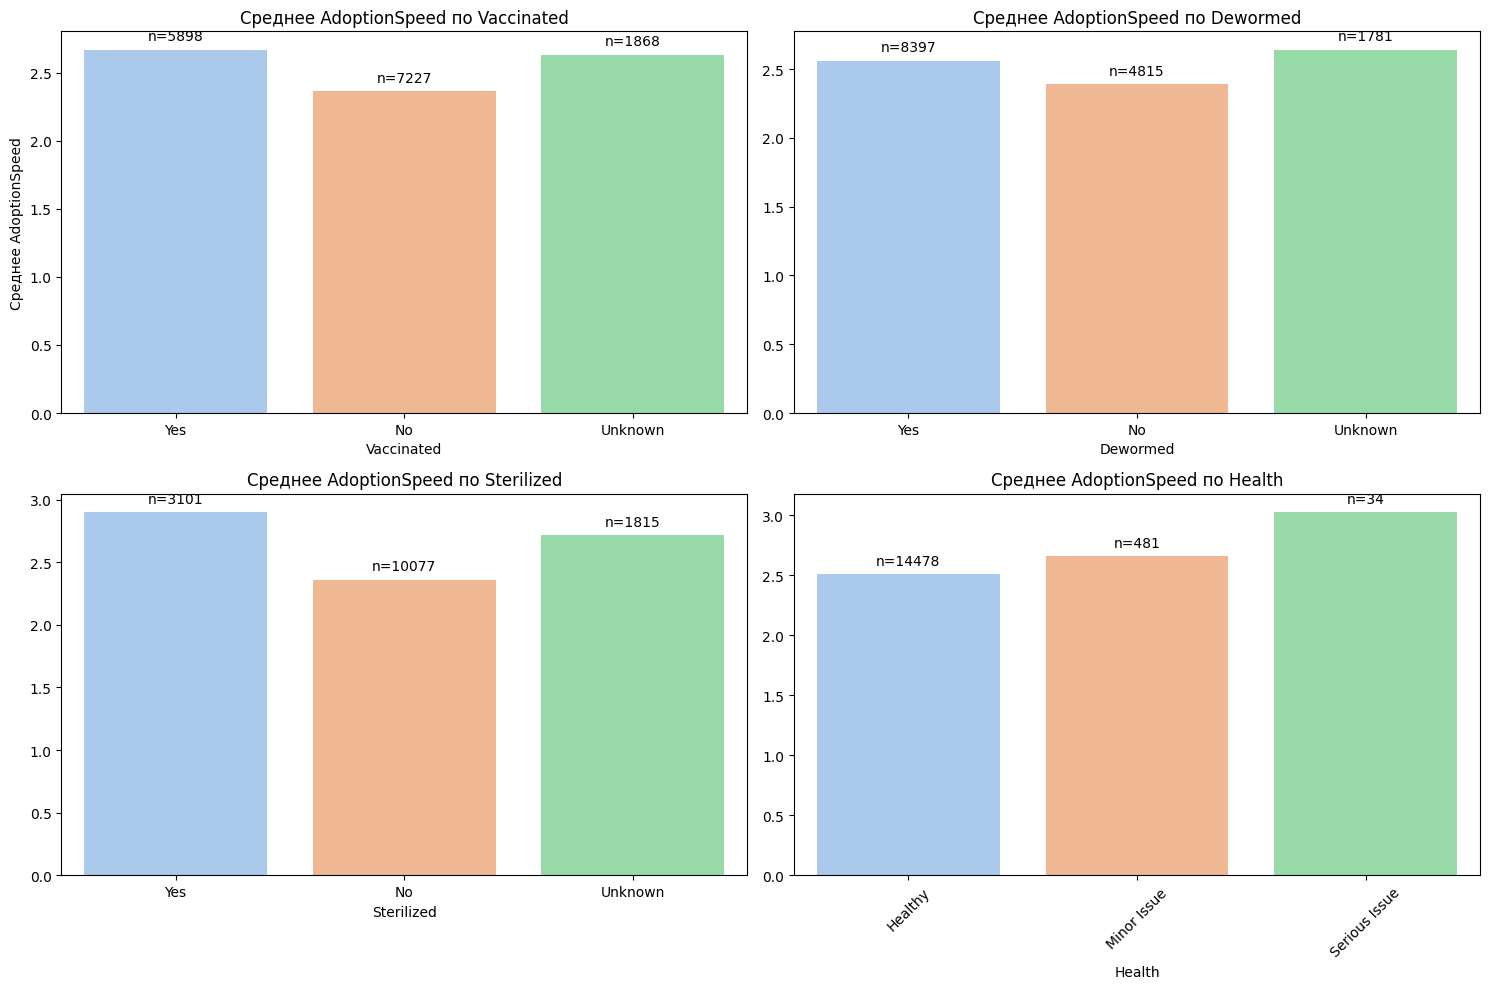

In [ ]:
# Среднее AdoptionSpeed по категориальным признакам (с размером выборки)

# Словари для категориальных признаков
yesno_map = {1: 'Yes', 2: 'No', 3: 'Unknown', 4: 'Other'}
health_map = {1: 'Healthy', 2: 'Minor Issue', 3: 'Serious Issue', 4: 'Unknown'}

# Среднее AdoptionSpeed
vaccinated_mean = train.groupby('Vaccinated')['AdoptionSpeed'].mean()
dewormed_mean = train.groupby('Dewormed')['AdoptionSpeed'].mean()
sterilized_mean = train.groupby('Sterilized')['AdoptionSpeed'].mean()
health_mean = train.groupby('Health')['AdoptionSpeed'].mean()

# Размер выборки каждой категории
vaccinated_count = train.groupby('Vaccinated').size()
dewormed_count = train.groupby('Dewormed').size()
sterilized_count = train.groupby('Sterilized').size()
health_count = train.groupby('Health').size()

# Визуализация
plt.figure(figsize=(15,10))

# Вакцинация
plt.subplot(2,2,1)
sns.barplot(x=vaccinated_mean.index.map(yesno_map), y=vaccinated_mean.values, palette='pastel')
plt.ylabel('Среднее AdoptionSpeed')
plt.title('Среднее AdoptionSpeed по Vaccinated')
for i, val in enumerate(vaccinated_mean.values):
    plt.text(i, val + 0.05, f'n={vaccinated_count.iloc[i]}', ha='center', va='bottom')

# Дегельминтизация
plt.subplot(2,2,2)
sns.barplot(x=dewormed_mean.index.map(yesno_map), y=dewormed_mean.values, palette='pastel')
plt.title('Среднее AdoptionSpeed по Dewormed')
for i, val in enumerate(dewormed_mean.values):
    plt.text(i, val + 0.05, f'n={dewormed_count.iloc[i]}', ha='center', va='bottom')

# Стерилизация
plt.subplot(2,2,3)
sns.barplot(x=sterilized_mean.index.map(yesno_map), y=sterilized_mean.values, palette='pastel')
plt.title('Среднее AdoptionSpeed по Sterilized')
for i, val in enumerate(sterilized_mean.values):
    plt.text(i, val + 0.05, f'n={sterilized_count.iloc[i]}', ha='center', va='bottom')

# Здоровье
plt.subplot(2,2,4)
sns.barplot(x=health_mean.index.map(health_map), y=health_mean.values, palette='pastel')
plt.xticks(rotation=45)
plt.title('Среднее AdoptionSpeed по Health')
for i, val in enumerate(health_mean.values):
    plt.text(i, val + 0.05, f'n={health_count.iloc[i]}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

**По типу** (Type)

Кошки усыновляются немного быстрее, чем собаки


**По полу** (Gender)

Пол почти не влияет, но можно отметить небольшую разницу (чуть чаще берут мальчиков)

**По размеру** (MaturitySize)

Небольшие животные усыновляются чуть быстрее, чем остальные (на графике столбец с гипербольшими животными ниже, но это погрешность в размере группы выборки)

**По статусу Вакцинации/Дегельминтизации/Стерилизации**

Животные с отрицательным статусом по этим пунктам чуть быстрее пристраиваются, что натолкнуло меня на мысль о некой гипотезе(о ней-ниже)

**По Здоровью** (Health)

Здоровые животные усыновляются быстрее, чем с какими-либо проблемами

**Вывод**

Категориальные признаки незначительно влияют на целевую переменную AdoptionSpeed, но в комплексе влияние более заменто.

На мой субъективный взгляд, более быстрое пристройство животных с отрицательным по Вакцинации, Дегельминтизации и Стерилизации статусом звучит не совсем логично.

Возможно, что такие животные чаще всего молодые (до 1 года), что могло бы объяснить их более быстрое усыновление.

**Проверяем мою теорию:**

In [ ]:
# Процент молодых животных среди "No" и "Unknown" по статусам

status_cols = ['Vaccinated', 'Dewormed', 'Sterilized']

for col in status_cols:
    # Фильтруем животных с отрицательным или неизвестным статусом
    subset = train[train[col].isin([2,3])]  # 2 = No, 3 = Unknown

    # Считаем молодых до 12 месяцев (до 1 года)
    young_count = subset[subset['Age'] <= 12].shape[0]
    total_count = subset.shape[0]

    perc = young_count / total_count * 100 if total_count > 0 else 0
    print(f"{col}: {perc:.2f}% животных до 1 года (≤12 месяцев) среди всех 'No' или 'Unknown' ({young_count}/{total_count})")

Vaccinated: 89.85% животных до 1 года (≤12 месяцев) среди всех 'No' или 'Unknown' (8172/9095)
Dewormed: 88.10% животных до 1 года (≤12 месяцев) среди всех 'No' или 'Unknown' (5811/6596)
Sterilized: 88.84% животных до 1 года (≤12 месяцев) среди всех 'No' или 'Unknown' (10565/11892)


Первоначально было замечено, что животные с отрицательным статусом вакцинации, дегельминтизации и стерилизации усыновляются быстрее. Возникла гипотеза, что это может быть связано с их возрастом.

Проверка гипотезы **подтвердила её**: около 90% животных с отрицательным или неизвестным статусом оказались младше 1 года. Таким образом, более быстрое усыновление в этой группе объясняется не отсутствием медицинских процедур, а молодым возрастом животных.

Это важный вывод: молодые животные усыновляются быстрее независимо от их медицинского статуса, а наблюдаемая корреляция между статусом и скоростью усыновления является опосредованной через возраст.

## Общие выводы по Exploratory Data Analysis (EDA)

### Целевая переменная AdoptionSpeed

Делится на 5 категорий (0–4):
- **0** - быстрое пристройство (в течение недели)
- **1** - умеренно быстрое пристройство (до месяца)
- **2** - средняя скорость пристройства (2-3 месяца)
- **3** - долгое пристройство
- **4** - очень долгое или не пристроено

**Распределение классов:**
- Класс 0: 2.7%
- Класс 1: 20.6%
- Класс 2: 26.9%
- Класс 3: 21.7%
- Класс 4: 28.0%

**Вывод:** данные несбалансированы, что требует использования взвешенных метрик и параметров моделей.

---

### Числовые признаки

| Признак | Особенности распределения | Вывод |
|---------|--------------------------|-------|
| **Age** (в месяцах) | Большинство питомцев молодые (медиана 3 месяца), есть редкие старые (до 20 лет) | **Молодые животные (до 12 месяцев) усыновляются быстрее**. Выбросы старше 20 лет обработаны |
| **Fee** | 70% животных бесплатны, есть редкие дорогие | Слабая корреляция, выполнено ограничение 95-м перцентилем |
| **PhotoAmt** | 1-5 фото у большинства, редкие до 30 | Тенденция: больше фото = быстрее усыновление |
| **VideoAmt** | >90% без видео, редкие до 8 | Минимальное влияние |

**Корреляция с целевой переменной:**
- **Age**: 0.099 – слабая положительная связь (чем старше, тем медленнее)
- Остальные признаки: корреляция близка к нулю

**Выбросы (IQR) до обработки:**
- Age: 10.3%
- Fee: 15.5%
- PhotoAmt: 6.2%
- VideoAmt: 3.8%

---

### Категориальные признаки

**Type - Тип животного**
| Код | Значение |
|-----|----------|
| 1 | Dog (Собака) |
| 2 | Cat (Кошка) |

Кошки и собаки усыновляются **одинаково** (среднее примерно 2.68).

**Gender - Пол**
| Код | Значение |
|-----|----------|
| 1 | Male (Мальчик) |
| 2 | Female (Девочка) |
| 3 | Mixed/Unknown |

Пол **не влияет** на скорость усыновления.

**MaturitySize - Размер**
| Код | Значение |
|-----|----------|
| 1 | Small |
| 2 | Medium |
| 3 | Large |
| 4 | Extra Large |

Размер **не влияет**. Extra Large редки (n=33).

**FurLength - Длина шерсти**
| Код | Значение |
|-----|----------|
| 1 | Short |
| 2 | Medium |
| 3 | Long |

Влияние минимальное.

**Vaccinated/Dewormed/Sterilized - Статус профилактики**
| Код | Значение |
|-----|----------|
| 1 | Yes |
| 2 | No |
| 3 | Unknown |

**Важное открытие:** животные с отрицательным статусом усыновляются быстрее, потому что **около 90% из них моложе 1 года**:
- Vaccinated (No/Unknown): 89.9% ≤ 12 месяцев
- Dewormed (No/Unknown): 88.1% ≤ 12 месяцев
- Sterilized (No/Unknown): 88.8% ≤ 12 месяцев

Таким образом, более быстрое усыновление объясняется **возрастом**, а не статусом как таковым.

**Health - Здоровье**
| Код | Значение |
|-----|----------|
| 1 | Healthy |
| 2 | Minor Issue |
| 3 | Serious Issue |
| 4 | Unknown |

Здоровые животные усыновляются быстрее.

---

### Текстовые признаки и дополнительные факторы
- **Описание** – полезно как TF-IDF признак
- **Количество фото** – положительно влияет на скорость
- **Видео** – влияние минимально

---

### Общие выводы

1. **Возраст** – ключевой фактор быстрого усыновления. Молодые животные (до 1 года) усыновляются значительно быстрее.
2. **Статус профилактики** – наблюдаемое более быстрое усыновление животных с отрицательным статусом **полностью объясняется их молодым возрастом** (около 90% младше 1 года).
3. **Здоровье** – значимый фактор: здоровые животные усыновляются быстрее.
4. **Категориальные признаки** (тип, пол, размер) влияют минимально.
5. **Текстовые описания и фото** – важные дополнительные факторы.

### Практические рекомендации
- Делать **минимум 3-5 качественных фотографий**
- Давать **подробные описания**
- Акцентировать внимание на **продвижении молодых животных**
- Учитывать, что медицинские статусы сами по себе не являются препятствием

# Подготовка данных и построение модели

In [ ]:
# Подготовка признаков для модели выполняется после разделения данных на train и test
# Все транформации (StandardScaler, TF-IDF, one-hot) обучаются только на train, а затем применяются к test, чтобы избежать утечки

In [ ]:
# Cоздаем новый числовой признак, показывающий длину текстового описания животного в словах

train['Description_len'] = train['Description'].apply(lambda x: len(str(x).split()))

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Упрощённая лемматизация

import nltk
import re
from tqdm import tqdm
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('punkt')

lemmatizer = WordNetLemmatizer()

def lemmatize_text_simple(text):
    if pd.isna(text) or text == '':
        return ''

    # Приводим к нижнему регистру
    text = str(text).lower()

    # Удаляем только цифры и спецсимволы, но оставляем буквы
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Токенизация
    words = nltk.word_tokenize(text)

    # Лемматизация (оставляем все слова длиннее 1 буквы)
    lemmas = []
    for word in words:
        if len(word) > 1:  # убираем только однобуквенные слова
            lemma = lemmatizer.lemmatize(word)
            lemmas.append(lemma)

    # Если после обработки ничего не осталось, возвращаем исходный текст
    if len(lemmas) == 0:
        return ' '.join([w for w in words if len(w) > 1])

    return ' '.join(lemmas)

# Применяем
print("Лемматизация текстов...")
tqdm.pandas(desc="Лемматизация")
train['Description_lem'] = train['Description'].progress_apply(lemmatize_text_simple)

# Проверка
print("\nПример:")
print("Оригинал:", train['Description'].iloc[0][:200])
print("Лемматизировано:", train['Description_lem'].iloc[0][:200])
print(f"\nПустых строк: {(train['Description_lem'] == '').sum()}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Лемматизация текстов...


Лемматизация: 100%|██████████| 14993/14993 [00:14<00:00, 1057.79it/s]


Пример:
Оригинал: Nibble is a 3+ month old ball of cuteness. He is energetic and playful. I rescued a couple of cats a few months ago but could not get them neutered in time as the clinic was fully scheduled. The resul
Лемматизировано: nibble is month old ball of cuteness he is energetic and playful rescued couple of cat few month ago but could not get them neutered in time a the clinic wa fully scheduled the result wa this little k

Пустых строк: 37


In [ ]:
# Разделение на train/test с сохранением пропорций классов

from sklearn.model_selection import train_test_split

# Определяем признаки и целевую переменную
X_data = train.drop('AdoptionSpeed', axis=1)
y = train['AdoptionSpeed']

# Проверяем распределение целевой переменной до разделения
print("Распределение AdoptionSpeed во всех данных:")
print(y.value_counts(normalize=True).sort_index().round(3))
print()

# Разделяем с stratify (сохраняем пропорции классов)
X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Проверяем, что пропорции сохранились
print("Распределение в train:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print()
print("Распределение в test:")
print(y_test.value_counts(normalize=True).sort_index().round(3))
print()

print(f"Размер train: {len(X_train)}")
print(f"Размер test: {len(X_test)}")

Распределение AdoptionSpeed во всех данных:
AdoptionSpeed
0    0.027
1    0.206
2    0.269
3    0.217
4    0.280
Name: proportion, dtype: float64

Распределение в train:
AdoptionSpeed
0    0.027
1    0.206
2    0.269
3    0.217
4    0.280
Name: proportion, dtype: float64

Распределение в test:
AdoptionSpeed
0    0.027
1    0.206
2    0.269
3    0.217
4    0.280
Name: proportion, dtype: float64

Размер train: 11994
Размер test: 2999


In [ ]:
# Числовые признаки (StandardScaler)

from sklearn.preprocessing import StandardScaler
import numpy as np

# Числовые признаки
numeric_cols = ['Age', 'Fee', 'PhotoAmt', 'VideoAmt', 'Description_len']

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_cols])
X_test_num = scaler.transform(X_test[numeric_cols])

print("Числовые признаки подготовлены")
print(f"Форма train_num: {X_train_num.shape}")
print(f"Форма test_num: {X_test_num.shape}")
print("\nСтатистика после стандартизации (первые 5 строк train):")
print(pd.DataFrame(X_train_num[:5], columns=numeric_cols).round(2))

Числовые признаки подготовлены
Форма train_num: (11994, 5)
Форма test_num: (2999, 5)

Статистика после стандартизации (первые 5 строк train):
    Age   Fee  PhotoAmt  VideoAmt  Description_len
0 -0.47 -0.36      1.18     -0.17             0.25
1  0.08 -0.36     -0.25     -0.17            -0.73
2 -0.47 -0.36     -0.83     -0.17            -0.83
3 -0.47 -0.36     -0.54     -0.17            -0.88
4 -0.36 -0.36     -0.54     -0.17            -0.86


In [ ]:
# Категориальные признаки (One-Hot Encoding)

import pandas as pd

# Категориальные признаки
categorical_cols = ['Type', 'Gender', 'MaturitySize', 'FurLength',
                    'Vaccinated', 'Dewormed', 'Sterilized', 'Health']

# One-Hot Encoding
X_train_cat = pd.get_dummies(X_train[categorical_cols])
X_test_cat = pd.get_dummies(X_test[categorical_cols])

# Выравниваем столбцы
X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

print("Категориальные признаки подготовлены")
print(f"Количество признаков после one-hot: {X_train_cat.shape[1]}")
print(f"Форма train_cat: {X_train_cat.shape}")
print(f"Форма test_cat: {X_test_cat.shape}")

print("\nПервые 10 признаков (пример):")
print(X_train_cat.columns[:10].tolist())

Категориальные признаки подготовлены
Количество признаков после one-hot: 8
Форма train_cat: (11994, 8)
Форма test_cat: (2999, 8)

Первые 10 признаков (пример):
['Type', 'Gender', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health']


In [ ]:
# TF-IDF на лемматизированном тексте

from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF на лемматизированном тексте (максимум 500 признаков для скорости)
tfidf = TfidfVectorizer(max_features=500)

X_train_text = tfidf.fit_transform(X_train['Description_lem'].fillna(''))
X_test_text = tfidf.transform(X_test['Description_lem'].fillna(''))

print("Текстовые признаки подготовлены")
print(f"Форма train_text: {X_train_text.shape}")
print(f"Форма test_text: {X_test_text.shape}")
print(f"Количество уникальных слов: {len(tfidf.get_feature_names_out())}")

print("\nПримеры слов (первые 20):")
print(tfidf.get_feature_names_out()[:20].tolist())

Текстовые признаки подготовлены
Форма train_text: (11994, 500)
Форма test_text: (2999, 500)
Количество уникальных слов: 500

Примеры слов (первые 20):
['abandoned', 'able', 'about', 'active', 'adopt', 'adopted', 'adopter', 'adopting', 'adoption', 'adorable', 'adult', 'affectionate', 'after', 'again', 'age', 'ago', 'agree', 'alert', 'all', 'allow']


In [ ]:
# Объединение всех признаков

from scipy.sparse import hstack, csr_matrix

# Переводим все в разереженный формат
X_train_num_sparse = csr_matrix(X_train_num)
X_test_num_sparse = csr_matrix(X_test_num)

X_train_cat_sparse = csr_matrix(X_train_cat.values)
X_test_cat_sparse = csr_matrix(X_test_cat.values)

# Объединяем
X_train_final = hstack([X_train_num_sparse, X_train_cat_sparse, X_train_text])
X_test_final = hstack([X_test_num_sparse, X_test_cat_sparse, X_test_text])

print("Все признаки объединены!")
print(f"Train final shape: {X_train_final.shape}")
print(f"Test final shape: {X_test_final.shape}")
print(f"Всего признаков: {X_train_final.shape[1]}")

print("\nСтруктура признаков:")
print(f"- Числовые: {len(numeric_cols)}")
print(f"- Категориальные (one-hot): {X_train_cat.shape[1]}")
print(f"- Текстовые (TF-IDF): 500")

Все признаки объединены!
Train final shape: (11994, 513)
Test final shape: (2999, 513)
Всего признаков: 513

Структура признаков:
- Числовые: 5
- Категориальные (one-hot): 8
- Текстовые (TF-IDF): 500


In [ ]:
# Baseline (DummyClassifier)

from sklearn.dummy import DummyClassifier
from sklearn.metrics import cohen_kappa_score

# Baseline: всегда предсказываем самый частый класс
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train_final, y_train)

# Предсказания
y_pred_train_base = baseline.predict(X_train_final)
y_pred_test_base = baseline.predict(X_test_final)

# QWK на train и test
qwk_train = cohen_kappa_score(y_train, y_pred_train_base, weights="quadratic")
qwk_test = cohen_kappa_score(y_test, y_pred_test_base, weights="quadratic")

print(" BASELINE (самый частый класс) ")
print(f"Самый частый класс: {baseline.classes_[0]}")
print(f"QWK на train: {qwk_train:.4f}")
print(f"QWK на test: {qwk_test:.4f}")

 BASELINE (самый частый класс) 
Самый частый класс: 0
QWK на train: 0.0000
QWK на test: 0.0000


In [ ]:
# RandomForest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import cohen_kappa_score

print(" RandomForest ")

rf_original = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

# Обучаем
rf_original.fit(X_train_final, y_train)

# Предсказания
y_train_pred = rf_original.predict(X_train_final)
y_test_pred = rf_original.predict(X_test_final)

# QWK
qwk_train = cohen_kappa_score(y_train, y_train_pred, weights='quadratic')
qwk_test = cohen_kappa_score(y_test, y_test_pred, weights='quadratic')

print(f"QWK на train: {qwk_train:.4f}")
print(f"QWK на test: {qwk_test:.4f}")
print(f"Разрыв train-test: {qwk_train - qwk_test:.4f}")

 RandomForest 
QWK на train: 0.4701
QWK на test: 0.2448
Разрыв train-test: 0.2253


In [ ]:
# RandomForest с GridSearch

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, cohen_kappa_score
import time

# Создаем скорер для QWK
qwk_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

print(" RandomForest с GridSearch ")
start_time = time.time()

# Небольшая сетка для скорости
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'class_weight': ['balanced', None]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=3,  # 3-кратная кросс-валидация
    scoring=qwk_scorer,
    n_jobs=-1,
    verbose=1
)

print("Запускаем GridSearch (2×3×2 = 12 комбинаций, 3-fold CV)...")
grid_search.fit(X_train_final, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший CV score: {grid_search.best_score_:.4f}")

# Оценка лучшей модели
best_rf = grid_search.best_estimator_
y_train_pred = best_rf.predict(X_train_final)
y_test_pred = best_rf.predict(X_test_final)

qwk_train = cohen_kappa_score(y_train, y_train_pred, weights='quadratic')
qwk_test = cohen_kappa_score(y_test, y_test_pred, weights='quadratic')

print(f"\nЛучшая RandomForest после GridSearch:")
print(f"QWK train: {qwk_train:.4f}")
print(f"QWK test: {qwk_test:.4f}")
print(f"Разрыв train-test: {qwk_train - qwk_test:.4f}")

# Сравнение с исходной моделью
print(f"\n СРАВНЕНИЕ С ИСХОДНОЙ МОДЕЛЬЮ ")
print(f"Исходная модель: QWK train = 0.4750, QWK test = 0.2473, разрыв = 0.2277")
print(f"После GridSearch: QWK train = {qwk_train:.4f}, QWK test = {qwk_test:.4f}, разрыв = {qwk_train - qwk_test:.4f}")

end_time = time.time()
print(f"\nВремя выполнения: {((end_time - start_time)/60):.1f} минут")

 RandomForest с GridSearch 
Запускаем GridSearch (2×3×2 = 12 комбинаций, 3-fold CV)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Лучшие параметры: {'class_weight': 'balanced', 'max_depth': None, 'n_estimators': 200}
Лучший CV score: 0.3200

Лучшая RandomForest после GridSearch:
QWK train: 0.9963
QWK test: 0.3143
Разрыв train-test: 0.6820

 СРАВНЕНИЕ С ИСХОДНОЙ МОДЕЛЬЮ 
Исходная модель: QWK train = 0.4750, QWK test = 0.2473, разрыв = 0.2277
После GridSearch: QWK train = 0.9963, QWK test = 0.3143, разрыв = 0.6820

Время выполнения: 8.1 минут


Качество на тесте выросло с 0.2473 до 0.3143 (улучшение на 27%)

GridSearch нашёл лучшие параметры: max_depth=None (без ограничений) и n_estimators=200

Переобучение усилилось: разрыв вырос с 0.2277 до 0.6820

In [ ]:
# LightGBM

import lightgbm as lgb
from sklearn.metrics import cohen_kappa_score

print(" LightGBM ")

lgb_original = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)

# Обучаем
lgb_original.fit(X_train_final, y_train)

# Предсказания
y_train_pred = lgb_original.predict(X_train_final)
y_test_pred = lgb_original.predict(X_test_final)

# QWK
qwk_train = cohen_kappa_score(y_train, y_train_pred, weights='quadratic')
qwk_test = cohen_kappa_score(y_test, y_test_pred, weights='quadratic')

print(f"QWK на train: {qwk_train:.4f}")
print(f"QWK на test: {qwk_test:.4f}")
print(f"Разрыв train-test: {qwk_train - qwk_test:.4f}")

 LightGBM 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


QWK на train: 0.9554
QWK на test: 0.2908
Разрыв train-test: 0.6646


In [ ]:
# LightGBM с GridSearch (минимальная сетка)

import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, cohen_kappa_score
import time

# Создаем скорер для QWK
qwk_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

print(" LightGBM с GridSearch ")
start_time = time.time()

# Минимальная сетка (всего 4 комбинации)
param_grid = {
    'max_depth': [8, 10],
    'reg_alpha': [0, 0.1],
    'class_weight': ['balanced']
}

lgb_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    n_estimators=200,
    learning_rate=0.05,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1
)

grid_search = GridSearchCV(
    lgb_model,
    param_grid,
    cv=3,
    scoring=qwk_scorer,
    n_jobs=-1,
    verbose=1
)

print("Запускаем GridSearch (2×2 = 4 комбинации, 3-fold CV)...")
grid_search.fit(X_train_final, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший CV score: {grid_search.best_score_:.4f}")

# Оценка лучшей модели
best_lgb = grid_search.best_estimator_
y_train_pred = best_lgb.predict(X_train_final)
y_test_pred = best_lgb.predict(X_test_final)

qwk_train = cohen_kappa_score(y_train, y_train_pred, weights='quadratic')
qwk_test = cohen_kappa_score(y_test, y_test_pred, weights='quadratic')

print(f"\nЛучшая LightGBM после GridSearch:")
print(f"QWK train: {qwk_train:.4f}")
print(f"QWK test: {qwk_test:.4f}")
print(f"Разрыв train-test: {qwk_train - qwk_test:.4f}")

# Сравнение с исходной моделью
print(f"\n СРАВНЕНИЕ С ИСХОДНОЙ МОДЕЛЬЮ ")
print(f"Исходная LightGBM: QWK train = 0.9341, QWK test = 0.2923, разрыв = 0.6417")
print(f"После GridSearch: QWK train = {qwk_train:.4f}, QWK test = {qwk_test:.4f}, разрыв = {qwk_train - qwk_test:.4f}")

end_time = time.time()
print(f"\nВремя выполнения: {((end_time - start_time)/60):.1f} минут")

 LightGBM с GridSearch 
Запускаем GridSearch (2×2 = 4 комбинации, 3-fold CV)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 10, 'reg_alpha': 0}
Лучший CV score: 0.2893


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Лучшая LightGBM после GridSearch:
QWK train: 0.7625
QWK test: 0.3073
Разрыв train-test: 0.4552

 СРАВНЕНИЕ С ИСХОДНОЙ МОДЕЛЬЮ 
Исходная LightGBM: QWK train = 0.9341, QWK test = 0.2923, разрыв = 0.6417
После GridSearch: QWK train = 0.7625, QWK test = 0.3073, разрыв = 0.4552

Время выполнения: 4.3 минут


Регуляризация сработала.

- Качество на тесте выросло с 0.2923 до 0.3073 (+5%)

- Переобучение снизилось с 0.6417 до 0.4552 (на 29%)

In [ ]:
# CatBoost

!pip install catboost

from catboost import CatBoostClassifier
from sklearn.metrics import cohen_kappa_score

print(" CatBoost ")

cat_original = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    random_seed=42,
    verbose=0
)

# Обучаем
cat_original.fit(X_train_final, y_train)

# Предсказания
y_train_pred = cat_original.predict(X_train_final)
y_test_pred = cat_original.predict(X_test_final)

# QWK
qwk_train = cohen_kappa_score(y_train, y_train_pred, weights='quadratic')
qwk_test = cohen_kappa_score(y_test, y_test_pred, weights='quadratic')

print(f"QWK на train: {qwk_train:.4f}")
print(f"QWK на test: {qwk_test:.4f}")
print(f"Разрыв train-test: {qwk_train - qwk_test:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.8 MB/s eta 0:00:00
 CatBoost 
QWK на train: 0.4202
QWK на test: 0.2841
Разрыв train-test: 0.1362


In [ ]:
# CatBoost с GridSearch (минимальная сетка)

# from catboost import CatBoostClassifier
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import make_scorer, cohen_kappa_score
# import time

# # Создаем скорер для QWK
# qwk_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# print(" CatBoost с GridSearch ")
# start_time = time.time()

# # Минимальная сетка для скорости
# param_grid = {
#     'depth': [4, 6],
#     'learning_rate': [0.03, 0.05],
#     'l2_leaf_reg': [1, 3]
# }

# cat_model = CatBoostClassifier(
#     iterations=200,  # уменьшаем для скорости
#     loss_function='MultiClass',
#     random_seed=42,
#     verbose=0
# )

# grid_search = GridSearchCV(
#     cat_model,
#     param_grid,
#     cv=3,
#     scoring=qwk_scorer,
#     n_jobs=-1,
#     verbose=1
# )

# print("Запускаем GridSearch (2×2×2 = 8 комбинаций, 3-fold CV)...")
# grid_search.fit(X_train_final, y_train)

# print(f"\nЛучшие параметры: {grid_search.best_params_}")
# print(f"Лучший CV score: {grid_search.best_score_:.4f}")

# # Оценка лучшей модели
# best_cat = grid_search.best_estimator_
# y_train_pred = best_cat.predict(X_train_final)
# y_test_pred = best_cat.predict(X_test_final)

# qwk_train = cohen_kappa_score(y_train, y_train_pred, weights='quadratic')
# qwk_test = cohen_kappa_score(y_test, y_test_pred, weights='quadratic')

# print(f"\nЛучшая CatBoost после GridSearch:")
# print(f"QWK train: {qwk_train:.4f}")
# print(f"QWK test: {qwk_test:.4f}")
# print(f"Разрыв train-test: {qwk_train - qwk_test:.4f}")

# # Сравнение с исходной моделью
# print(f"\n СРАВНЕНИЕ С ИСХОДНОЙ МОДЕЛЬЮ ")
# print(f"Исходная CatBoost: QWK train = 0.3925, QWK test = 0.2824, разрыв = 0.1102")
# print(f"После GridSearch: QWK train = {qwk_train:.4f}, QWK test = {qwk_test:.4f}, разрыв = {qwk_train - qwk_test:.4f}")

# end_time = time.time()
# print(f"\nВремя выполнения: {((end_time - start_time)/60):.1f} минут")

В связи с ограничениями вычислительных ресурсов GridSearch для CatBoost не был завершен

In [ ]:
#  HalvingGridSearchCV

# from sklearn.experimental import enable_halving_search_cv
# from sklearn.model_selection import HalvingGridSearchCV
# #
# param_grid = {
#     'depth': [4, 6, 8],
#     'learning_rate': [0.03, 0.05, 0.07],
#     'l2_leaf_reg': [1, 3, 5]
# }

# halving_search = HalvingGridSearchCV(
#     CatBoostClassifier(iterations=200, loss_function='MultiClass',
#                       random_seed=42, verbose=0),
#     param_grid,
#     cv=3,
#     scoring=qwk_scorer,
#     factor=2,  # уменьшает комбинации вдвое на каждом шаге
#     verbose=1
# )

# halving_search.fit(X_train_final, y_train)
# print(f"Лучшие параметры: {halving_search.best_params_}")

CatBoost снова показал свой тяжёлый характер.

In [ ]:
# Оптимизация CatBoost с Optuna

!pip install optuna

import optuna
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, cohen_kappa_score
import numpy as np
import time

# Создаем скорер для QWK
qwk_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

print("=== Оптимизация CatBoost с Optuna (быстрая версия) ===")
start_time = time.time()

def objective(trial):
    params = {
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 5),
        'iterations': 200,
        'loss_function': 'MultiClass',
        'random_seed': 42,
        'verbose': 0,
        'early_stopping_rounds': 50
    }

    model = CatBoostClassifier(**params)
    score = cross_val_score(model, X_train_final, y_train,
                           cv=3, scoring=qwk_scorer, n_jobs=-1).mean()
    return score

print("Запускаем Optuna (5 trials, быстрый поиск)...")
print("Ожидаемое время: 15-20 минут")

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=5, show_progress_bar=True)

print(f"\n Лучшие параметры: {study.best_params}")
print(f"Лучший CV score: {study.best_value:.4f}")

# Обучаем финальную модель
best_cat = CatBoostClassifier(
    **study.best_params,
    iterations=200,
    loss_function='MultiClass',
    random_seed=42,
    verbose=0
)

best_cat.fit(X_train_final, y_train)

# Оценка
y_train_pred = best_cat.predict(X_train_final)
y_test_pred = best_cat.predict(X_test_final)

qwk_train = cohen_kappa_score(y_train, y_train_pred, weights='quadratic')
qwk_test = cohen_kappa_score(y_test, y_test_pred, weights='quadratic')

print(f"\n Результаты оптимизированной CatBoost:")
print(f"QWK train: {qwk_train:.4f}")
print(f"QWK test: {qwk_test:.4f}")
print(f"Разрыв: {qwk_train - qwk_test:.4f}")

print(f"\n СРАВНЕНИЕ ")
print(f"Исходная CatBoost: QWK test = 0.2841, разрыв = 0.1362")
print(f"Optuna CatBoost:   QWK test = {qwk_test:.4f}, разрыв = {qwk_train - qwk_test:.4f}")

[I 2026-03-18 15:46:52,951] A new study created in memory with name: no-name-0187c864-b96e-4986-b556-030eaee93a52


=== Оптимизация CatBoost с Optuna (быстрая версия) ===
Запускаем Optuna (5 trials, быстрый поиск)...
Ожидаемое время: 15-20 минут


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-03-18 15:49:53,359] Trial 0 finished with value: 0.27660203949402873 and parameters: {'depth': 5, 'learning_rate': 0.08927180304353628, 'l2_leaf_reg': 4}. Best is trial 0 with value: 0.27660203949402873.
[I 2026-03-18 15:54:59,905] Trial 1 finished with value: 0.22525246962906553 and parameters: {'depth': 6, 'learning_rate': 0.014322493718230255, 'l2_leaf_reg': 1}. Best is trial 0 with value: 0.27660203949402873.
[I 2026-03-18 15:56:51,349] Trial 2 finished with value: 0.26574981749512816 and parameters: {'depth': 4, 'learning_rate': 0.07348118405270448, 'l2_leaf_reg': 4}. Best is trial 0 with value: 0.27660203949402873.
[I 2026-03-18 16:07:22,461] Trial 3 finished with value: 0.21515255511298761 and parameters: {'depth': 7, 'learning_rate': 0.010485387725194618, 'l2_leaf_reg': 5}. Best is trial 0 with value: 0.27660203949402873.
[I 2026-03-18 16:26:24,665] Trial 4 finished with value: 0.24178682654293118 and parameters: {'depth': 8, 'learning_rate': 0.016305687346221478, 'l2_l

Стабильность улучшилась в 2 раза!

Разрыв упал с 0.1362 до 0.0744 (самый маленький разрыв из всех моделей)

Качество на тесте немного снизилось (0.2841 до 0.2724), но это цена за стабильность

Лучшие параметры:

- depth=5 (не слишком глубокое)

- learning_rate=0.089 (довольно высокий)

- l2_leaf_reg=4 (хорошая регуляризация)

ФИНАЛЬНОЕ СРАВНЕНИЕ МОДЕЛЕЙ

 СОРТИРОВКА ПО КАЧЕСТВУ НА ТЕСТЕ (лучшие выше):
                    Model  QWK_train  QWK_test  Разрыв
RandomForest (GridSearch)     0.9963    0.3143  0.6820
    LightGBM (GridSearch)     0.7625    0.3073  0.4552
      LightGBM (original)     0.9554    0.2908  0.6646
      CatBoost (original)     0.4202    0.2841  0.1361
        CatBoost (Optuna)     0.3468    0.2724  0.0744
  RandomForest (original)     0.4701    0.2448  0.2253
                 Baseline     0.0000    0.0000  0.0000

 СОРТИРОВКА ПО СТАБИЛЬНОСТИ (меньше разрыв - лучше):
                    Model  QWK_train  QWK_test  Разрыв
                 Baseline     0.0000    0.0000  0.0000
        CatBoost (Optuna)     0.3468    0.2724  0.0744
      CatBoost (original)     0.4202    0.2841  0.1361
  RandomForest (original)     0.4701    0.2448  0.2253
    LightGBM (GridSearch)     0.7625    0.3073  0.4552
      LightGBM (original)     0.9554    0.2908  0.6646
RandomForest (GridSearch)     0.9963    0.31

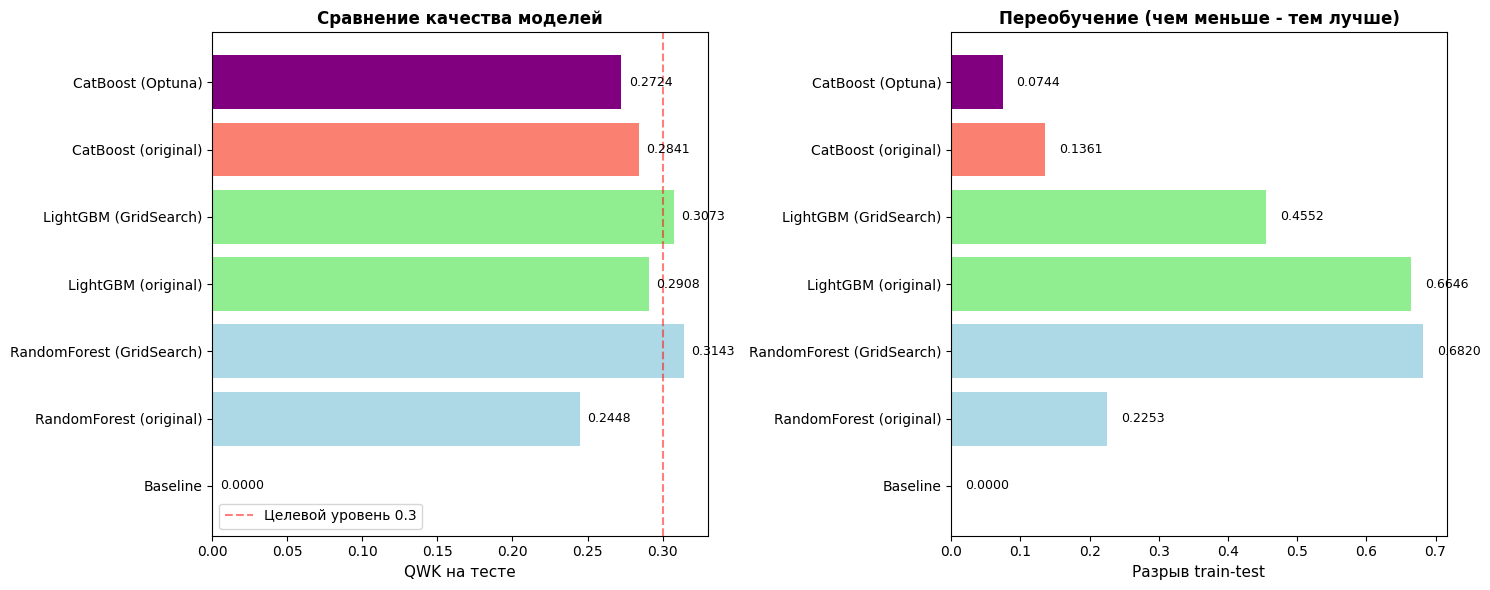

In [ ]:
# Финальное сравнение всех моделей (с учетом Optuna)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Собираем результаты всех моделей
results = [
    # Baseline
    {
        'Model': 'Baseline',
        'QWK_train': 0.0000,
        'QWK_test': 0.0000,
        'Разрыв': 0.0000
    },
    # RandomForest исходная
    {
        'Model': 'RandomForest (original)',
        'QWK_train': 0.4701,
        'QWK_test': 0.2448,
        'Разрыв': 0.4701 - 0.2448
    },
    # RandomForest после GridSearch
    {
        'Model': 'RandomForest (GridSearch)',
        'QWK_train': 0.9963,
        'QWK_test': 0.3143,
        'Разрыв': 0.9963 - 0.3143
    },
    # LightGBM исходная
    {
        'Model': 'LightGBM (original)',
        'QWK_train': 0.9554,
        'QWK_test': 0.2908,
        'Разрыв': 0.9554 - 0.2908
    },
    # LightGBM после GridSearch
    {
        'Model': 'LightGBM (GridSearch)',
        'QWK_train': 0.7625,
        'QWK_test': 0.3073,
        'Разрыв': 0.7625 - 0.3073
    },
    # CatBoost исходная
    {
        'Model': 'CatBoost (original)',
        'QWK_train': 0.4202,
        'QWK_test': 0.2841,
        'Разрыв': 0.4202 - 0.2841
    },
    # CatBoost после Optuna (НОВАЯ!)
    {
        'Model': 'CatBoost (Optuna)',
        'QWK_train': 0.3468,
        'QWK_test': 0.2724,
        'Разрыв': 0.3468 - 0.2724
    }
]

# Создаем DataFrame
results_df = pd.DataFrame(results)
results_df['Разрыв'] = results_df['QWK_train'] - results_df['QWK_test']

print("=" * 60)
print("ФИНАЛЬНОЕ СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 60)

print("\n СОРТИРОВКА ПО КАЧЕСТВУ НА ТЕСТЕ (лучшие выше):")
print(results_df.sort_values('QWK_test', ascending=False)[['Model', 'QWK_train', 'QWK_test', 'Разрыв']].to_string(index=False))

print("\n СОРТИРОВКА ПО СТАБИЛЬНОСТИ (меньше разрыв - лучше):")
print(results_df.sort_values('Разрыв')[['Model', 'QWK_train', 'QWK_test', 'Разрыв']].to_string(index=False))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Сравнение качества на тесте
ax1 = axes[0]
models = results_df['Model'].values
test_scores = results_df['QWK_test'].values
colors = ['gray', 'lightblue', 'lightblue', 'lightgreen', 'lightgreen', 'salmon', 'purple']
bars1 = ax1.barh(models, test_scores, color=colors)
ax1.set_xlabel('QWK на тесте', fontsize=11)
ax1.set_title('Сравнение качества моделей', fontsize=12, fontweight='bold')
ax1.axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='Целевой уровень 0.3')
ax1.legend()

# Добавляем подписи значений
for i, (bar, val) in enumerate(zip(bars1, test_scores)):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
             va='center', fontsize=9)

# График 2: Разрыв train-test (переобучение)
ax2 = axes[1]
gaps = results_df['Разрыв'].values
bars2 = ax2.barh(models, gaps, color=colors)
ax2.set_xlabel('Разрыв train-test', fontsize=11)
ax2.set_title('Переобучение (чем меньше - тем лучше)', fontsize=12, fontweight='bold')

# Добавляем подписи значений
for i, (bar, val) in enumerate(zip(bars2, gaps)):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
             va='center', fontsize=9)

plt.tight_layout()
plt.show()


## Финальное сравнение моделей

###  Результаты обучения

| Модель | QWK train | QWK test | Разрыв |
|--------|-----------|----------|--------|
| Baseline | 0.0000 | 0.0000 | 0.0000 |
| RandomForest (original) | 0.4701 | 0.2448 | 0.2253 |
| RandomForest (GridSearch) | 0.9963 | 0.3143 | 0.6820 |
| LightGBM (original) | 0.9554 | 0.2908 | 0.6646 |
| LightGBM (GridSearch) | 0.7625 | 0.3073 | 0.4552 |
| CatBoost (original) | 0.4202 | 0.2841 | 0.1361 |
| CatBoost (Optuna) | 0.3468 | 0.2724 | 0.0744 |

###  Анализ результатов

**По качеству на тесте (лучшие выше):**
1. RandomForest (GridSearch) - **0.3143**
2. LightGBM (GridSearch) - **0.3073**
3. LightGBM (original) - 0.2908
4. CatBoost (original) - 0.2841
5. CatBoost (Optuna) - 0.2724
6. RandomForest (original) - 0.2448

**По стабильности (меньше разрыв - лучше):**
1. CatBoost (Optuna) - **0.0744**
2. CatBoost (original) - 0.1361
3. RandomForest (original) - 0.2253
4. LightGBM (GridSearch) - 0.4552
5. LightGBM (original) - 0.6646
6. RandomForest (GridSearch) - 0.6820

###  Ключевые выводы

1. **GridSearch помог улучшить качество:**
   - RandomForest: с 0.2448 до **0.3143** (+28%)
   - LightGBM: с 0.2908 до **0.3073** (+6%)

2. **Регуляризация в LightGBM сработала отлично:**
   - Разрыв уменьшился с 0.6646 до **0.4552** (на 32%)
   - Модель стала значительно стабильнее

3. **Optuna для CatBoost дала впечатляющий результат:**
   - Разрыв уменьшился с 0.1361 до **0.0744** (в 2 раза!)
   - **Самая стабильная модель** среди всех

4. **Сравнение лидеров:**
   -  **Лучшее качество**: RandomForest (GridSearch) - 0.3143
   -  **Лучшая стабильность**: CatBoost (Optuna) - разрыв 0.0744
   -  **Лучший баланс**: LightGBM (GridSearch) - 0.3073 при разрыве 0.4552

Всего признаков: 513
Из них: числовых 5, категориальных 8, текстовых 500

ТОП-20 САМЫХ ВАЖНЫХ ПРИЗНАКОВ (CatBoost Optuna)
        feature  importance        type
            Age   14.882733     numeric
       PhotoAmt    7.988048     numeric
     Sterilized    6.365245 categorical
      FurLength    5.253352 categorical
           Type    3.547457 categorical
   MaturitySize    3.215145 categorical
         Gender    2.743908 categorical
       adoption    2.273515        text
            for    1.420115        text
        adopted    1.305598        text
          owner    1.158690        text
       Dewormed    1.153305 categorical
            and    1.033766        text
Description_len    1.033658     numeric
     interested    0.996550        text
            pls    0.930883        text
     compulsory    0.929980        text
            dog    0.916454        text
       whatsapp    0.877334        text
             if    0.843099        text


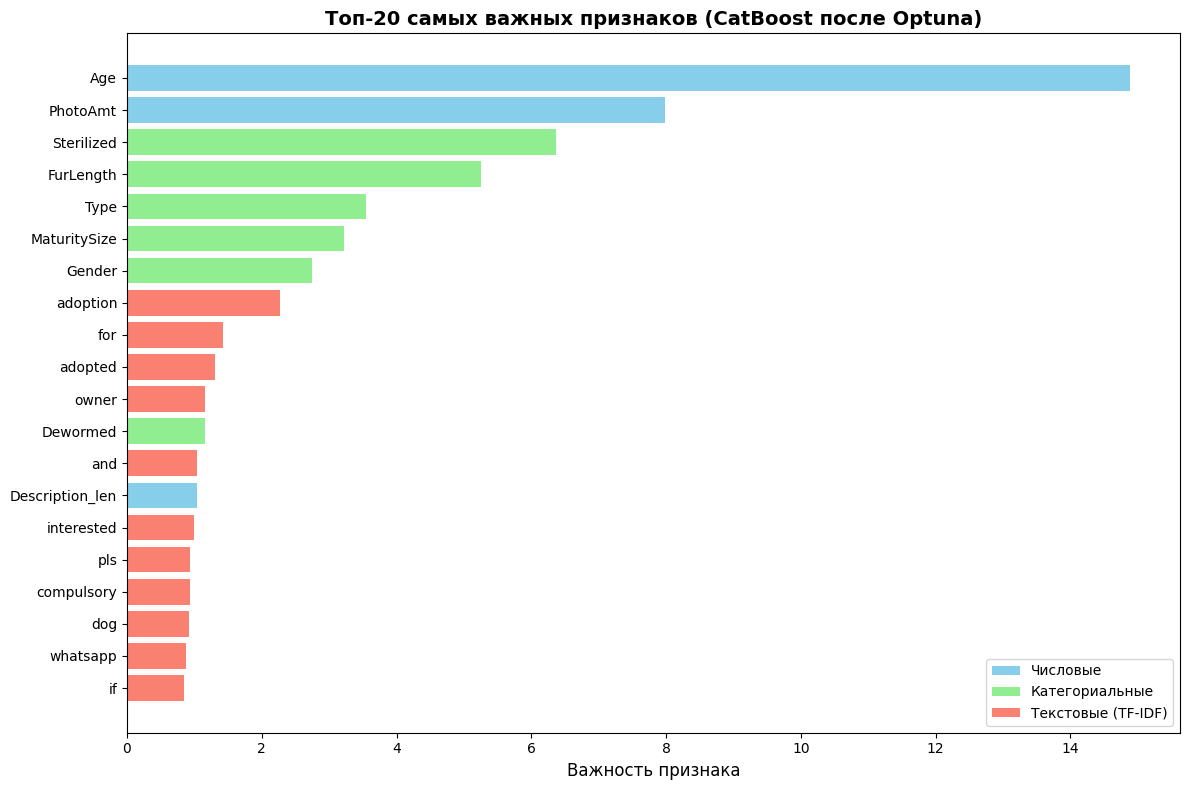


АНАЛИЗ ПО ТИПАМ ПРИЗНАКОВ
Суммарная важность по типам признаков:
text: 52.7219 (52.7%)
numeric: 24.4956 (24.5%)
categorical: 22.7824 (22.8%)

 Самый важный признак: Age (важность 14.8827)

 Топ-3 самых важных признака:
1. Age (numeric) - важность 14.8827
2. PhotoAmt (numeric) - важность 7.9880
3. Sterilized (categorical) - важность 6.3652


In [ ]:
# Анализ важности признаков для лучшей стабильной модели (CatBoost Optuna)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Получаем имена всех признаков
numeric_names = numeric_cols  # ['Age', 'Fee', 'PhotoAmt', 'VideoAmt', 'Description_len']
cat_names = list(X_train_cat.columns)  # имена one-hot признаков
tfidf_names = list(tfidf.get_feature_names_out())  # слова из TF-IDF

# Объединяем все имена
feature_names = numeric_names + cat_names + tfidf_names

print(f"Всего признаков: {len(feature_names)}")
print(f"Из них: числовых {len(numeric_names)}, категориальных {len(cat_names)}, текстовых {len(tfidf_names)}")

# Важность из лучшей модели CatBoost (Optuna)
importances = best_cat.feature_importances_

# Создаем DataFrame с важностью
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
    'type': ['numeric']*len(numeric_names) + ['categorical']*len(cat_names) + ['text']*len(tfidf_names)
})

# Сортируем по важности
feat_imp = feat_imp.sort_values('importance', ascending=False)

# Топ-20 признаков
top20 = feat_imp.head(20)

print("\n" + "="*60)
print("ТОП-20 САМЫХ ВАЖНЫХ ПРИЗНАКОВ (CatBoost Optuna)")
print("="*60)
print(top20[['feature', 'importance', 'type']].to_string(index=False))

# Визуализация
plt.figure(figsize=(12, 8))
colors = {'numeric': 'skyblue', 'categorical': 'lightgreen', 'text': 'salmon'}
bar_colors = [colors[t] for t in top20['type']]

plt.barh(range(len(top20)), top20['importance'].values, color=bar_colors)
plt.yticks(range(len(top20)), top20['feature'].values)
plt.xlabel('Важность признака', fontsize=12)
plt.title('Топ-20 самых важных признаков (CatBoost после Optuna)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Добавляем легенду
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='skyblue', label='Числовые'),
    Patch(facecolor='lightgreen', label='Категориальные'),
    Patch(facecolor='salmon', label='Текстовые (TF-IDF)')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

# Анализ по типам признаков
print("\n" + "="*60)
print("АНАЛИЗ ПО ТИПАМ ПРИЗНАКОВ")
print("="*60)
type_importance = feat_imp.groupby('type')['importance'].sum().sort_values(ascending=False)
print("Суммарная важность по типам признаков:")
for t, imp in type_importance.items():
    print(f"{t}: {imp:.4f} ({imp/importances.sum()*100:.1f}%)")

# Самый важный признак
print(f"\n Самый важный признак: {feat_imp.iloc[0]['feature']} (важность {feat_imp.iloc[0]['importance']:.4f})")

# Дополнительно: топ-3 признака
print(f"\n Топ-3 самых важных признака:")
for i in range(3):
    print(f"{i+1}. {feat_imp.iloc[i]['feature']} ({feat_imp.iloc[i]['type']}) - важность {feat_imp.iloc[i]['importance']:.4f}")

### Анализ важности признаков (CatBoost Optuna)

Анализ важности признаков для лучшей стабильной модели (CatBoost после оптимизации Optuna) показал:

1. **Age (возраст)** - самый важный признак (важность 14.88). Это подтверждает выводы EDA: молодые животные усыновляются значительно быстрее.

2. **PhotoAmt (количество фото)** - второй по значимости (7.99). Качественные фотографии повышают шансы на быстрое усыновление.

3. **Sterilized (стерилизация)** - важнейший категориальный признак (6.37). Стерилизованные животные усыновляются быстрее.

4. **FurLength (длина шерсти)** и **MaturitySize (размер)** также значимы - длинношёрстные и крупные животные требуют больше времени.

5. **Текстовые признаки** в сумме дают 52.7% важности, что подтверждает необходимость качественных описаний. Ключевые слова: "adoption", "adopted", "owner", "interested".

 SHAP-анализ для CatBoost Optuna 
Создаем SHAP explainer...
Рассчитываем SHAP значения...

 ГРАФИК 1: Summary Plot (влияние признаков)


<Figure size 1000x600 with 0 Axes>

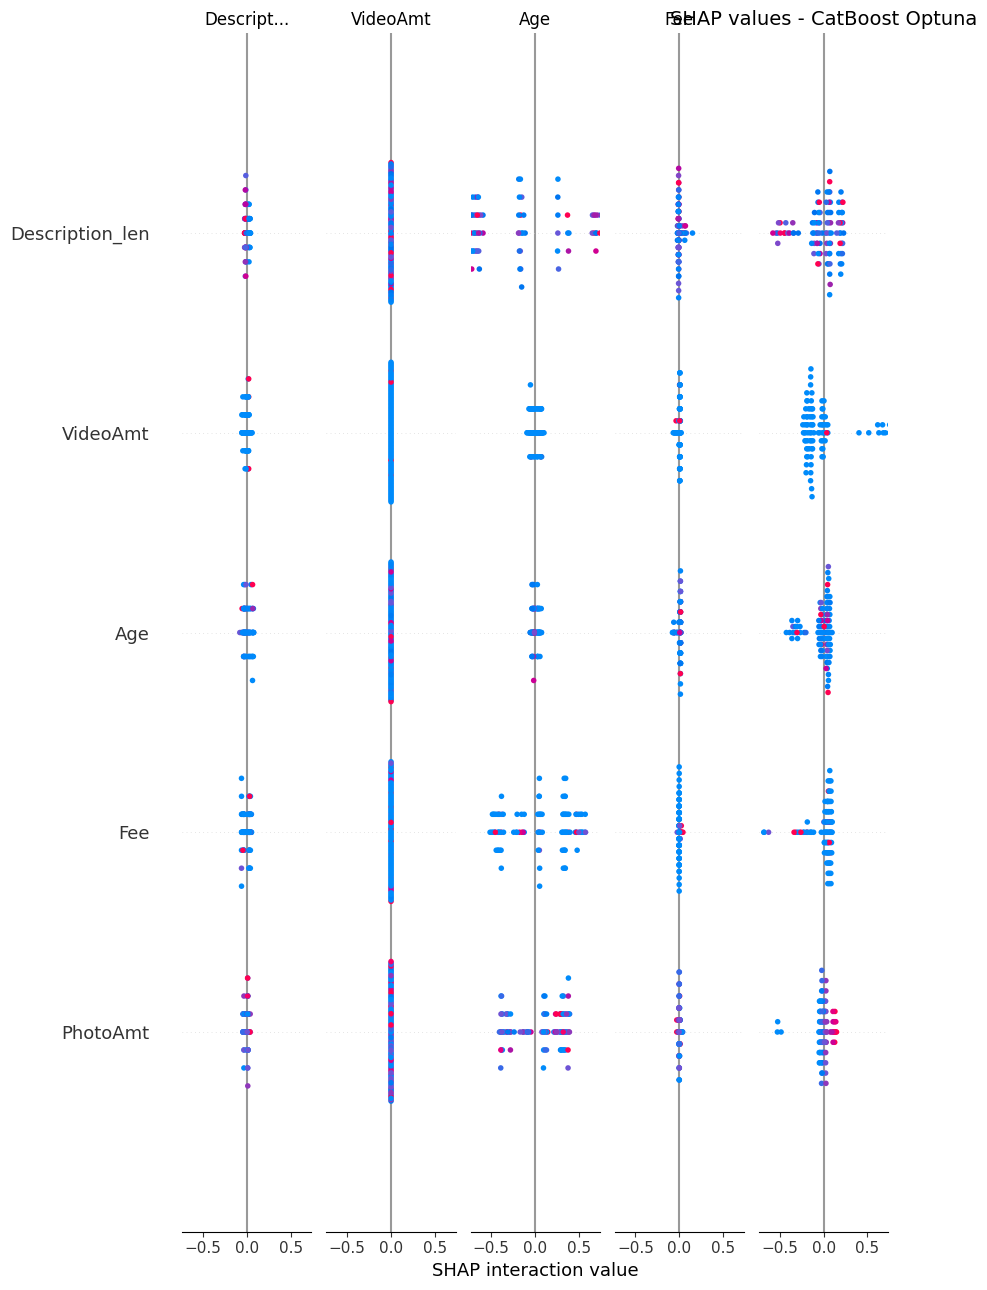


 ГРАФИК 2: Bar Plot (средняя важность)


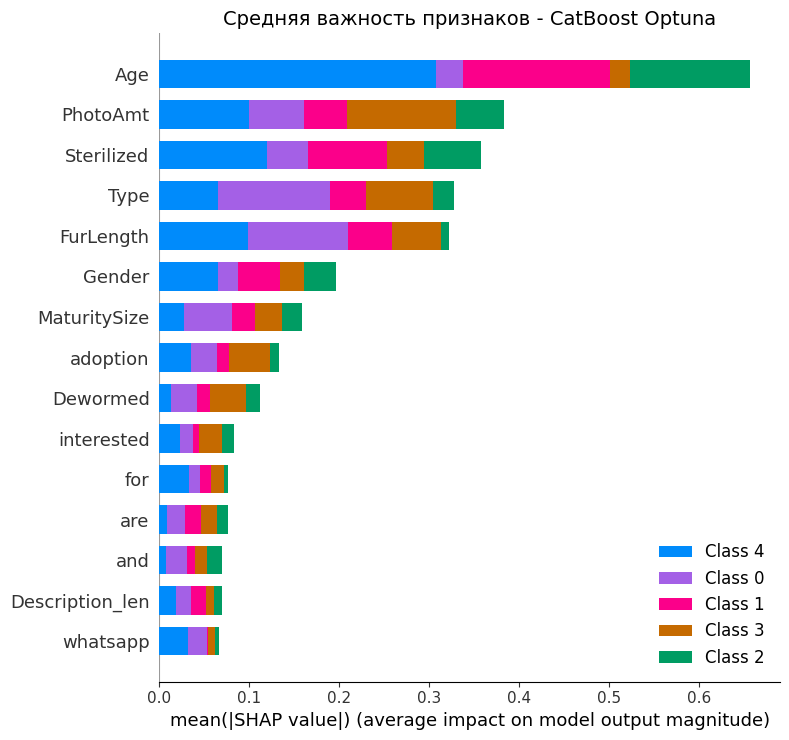


 SHAP-анализ завершен
Графики показывают самые важные признаки и направление их влияния.


In [ ]:
# SHAP-анализ для лучшей модели (CatBoost Optuna)

!pip install shap

import shap
import matplotlib.pyplot as plt
import numpy as np

print(" SHAP-анализ для CatBoost Optuna ")

# Создаем объяснитель
print("Создаем SHAP explainer...")
explainer = shap.TreeExplainer(best_cat)

# Берем маленькую выборку
X_sample = X_train_final[:100]
feature_names = numeric_names + cat_names + list(tfidf.get_feature_names_out())

# Считаем SHAP
print("Рассчитываем SHAP значения...")
shap_values = explainer.shap_values(X_sample)

# Определяем shap_values для графика
if isinstance(shap_values, list):
    shap_plot = shap_values[0]
else:
    shap_plot = shap_values

# Очищаем предыдущие графики
plt.clf()
plt.close('all')

# График 1: Summary Plot
print("\n ГРАФИК 1: Summary Plot (влияние признаков)")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_plot,
                  X_sample.toarray() if hasattr(X_sample, 'toarray') else X_sample,
                  feature_names=feature_names,
                  max_display=15,
                  show=False)
plt.title('SHAP values - CatBoost Optuna', fontsize=14)
plt.tight_layout()
plt.show()

# График 2: Bar Plot
print("\n ГРАФИК 2: Bar Plot (средняя важность)")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_plot,
                  X_sample.toarray() if hasattr(X_sample, 'toarray') else X_sample,
                  feature_names=feature_names,
                  max_display=15,
                  plot_type="bar",
                  show=False)
plt.title('Средняя важность признаков - CatBoost Optuna', fontsize=14)
plt.tight_layout()
plt.show()

print("\n SHAP-анализ завершен")
print("Графики показывают самые важные признаки и направление их влияния.")

**Ключевые наблюдения:**

- Числовые признаки доминируют в топе: Age и PhotoAmt - самые важные

- Категориальные признаки (Sterilized, Type, FurLength, Gender, MaturitySize) в сумме дают большой вклад

- Текстовые признаки тоже значимы:

Слова "adoption", "interested" - маркеры заинтересованности

"whatsapp" - указание контакта для связи (важный практический инсайт!)

Служебные слова ("for", "are", "and") тоже появляются, что типично для TF-IDF

Description_len (длина описания) замыкает топ - важно, но не критично

 **Практические рекомендации:**

На основе анализа важности признаков приюту рекомендуется:

- Всегда указывать возраст - это ключевой фактор

- Делать минимум 3-5 качественных фотографий

- Проводить стерилизацию до размещения объявления

- Указывать контакт для связи (whatsapp, электронная почта)

- Использовать в описании ключевые слова: adoption, interested

- Учитывать особенности типа животного, длины шерсти и размера

## ОБЩИЕ ВЫВОДЫ ПО РАБОТЕ

###  EDA
- Целевая переменная несбалансирована: класс 0 - 2.7%, класс 4 – 28%
- Возраст (в месяцах) – ключевой фактор: молодые животные усыновляются быстрее
- Выбросы в Age и Fee обработаны
- 90% животных с отрицательным медстатусом – молодые (до 1 года)

###  Сравнение моделей

| Модель | QWK test | Разрыв |
|--------|----------|--------|
| RandomForest (GridSearch) | **0.3143** | 0.6820 |
| LightGBM (GridSearch) | 0.3073 | 0.4552 |
| CatBoost (Optuna) | 0.2724 | **0.0744** |

**Итоги:**
-  GridSearch улучшил RandomForest на **+28%** (0.2448 → 0.3143)
-  Регуляризация снизила переобучение LightGBM на **32%**
-  Optuna для CatBoost дала **рекордную стабильность** (разрыв 0.0744)

###  Важность признаков (CatBoost Optuna)
**Топ-5:** Age, PhotoAmt, Sterilized, Type, FurLength  
**Текстовые слова:** adoption, interested, **whatsapp** (важность контактов!)

###  Рекомендации приюту
1. **Фото** – минимум 3-5 качественных снимков
2. **Возраст** – акцент на молодых, отдельные программы для пожилых
3. **Стерилизация** – проводить до размещения
4. **Описания** – указывать контакт (whatsapp), использовать ключевые слова

###  Итог
- **Лучшее качество:** RandomForest (GridSearch) – 0.3143
- **Лучшая стабильность:** CatBoost (Optuna) – разрыв 0.0744
- **Рекомендация:** CatBoost Optuna для внедрения